# HPN → Traditional ML Baseline (outcome_tag)

Turn each high-press **anchor freeze frame** (the same 107k graphs behind the HPN-GATv2)
into a **19-dim carrier-centric feature vector**, then train a **multinomial logistic
regression** that outputs the probability of each `outcome_tag` ∈ {`success`, `fail`, `neutral`}.

**Why carrier-centric, low-dim?** The label is the *frame outcome* and the ball carrier is the
focus, so instead of pooling the whole heterograph we read out only the **carrier's 1-hop
ego-graph** (its `pass` / `press` / `trap` / `near_enemy` edges) plus the **pressing threat on
the attacking players**. This collapses ~200 candidate features to 19, each interpretable.

> Unlike the GNN, the tabular model is **not** bound by the "don't hand-feed" rule — so we feed
> back the `press` pressure intensity and the `receiver_freedom` the GNN deliberately withheld.

**Leakage control:** features use only the current frame (no future ball direction); the
train/test split is **grouped by match** so frames from one game never straddle the split.

**Note on the two-head target:** here we model `outcome_tag` only. The `success ⟹ terminal`
constraint lives with the `terminal` head and is not enforced by this 3-class model.

In [1]:
# 1 — Imports & configuration
import os, json, math, time, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

HPN = os.environ.get("HPN_DIR", os.getcwd())                       # repo root (run notebook from here)
DATA_DIR = os.environ.get("STATSBOMB_DIR", os.path.dirname(HPN))   # parent holding raw StatsBomb JSON
EVENTS_DIR = os.environ.get("EVENTS_DIR", os.path.join(DATA_DIR, "events", "events"))
F360_DIR   = os.environ.get("F360_DIR", os.path.join(DATA_DIR, "three_sixty", "three_sixty"))
LABELS_CSV = os.path.join(HPN, "all_sequence_labels_v2.csv")
FEAT_PARQUET = os.path.join(HPN, "hpn_carrier_features.parquet")

import sys; sys.path.insert(0, os.path.join(HPN, "src"))
from pressure_distance_v2 import sigmoid_pressure, PressureParams

P = PressureParams()
K_PLAYER, K_LINE = P.k_player, P.k_line          # ≈0.824 / 1.649
D_PLAYER, D_LINE = P.D_star_player, P.D_star_line # 6.4 / 3.2
D_LANE = 1.2
K_LANE = math.pi / (math.sqrt(3) * 0.6)          # ≈3.02  (narrow pass corridor)
R_SOFT, P_EPS = 2.0, 0.05                         # pass soft boundary / press build threshold
TAU = 0.5                                         # "viable pass" / "pressed" threshold
SB_L, SB_W, M_L, M_W = 120.0, 80.0, 105.0, 68.0
OUTCOME_CLASSES = ["success", "fail", "neutral"]
print("config ready")

config ready


## Feature construction — 19 carrier-centric descriptors

All features are deterministic functions of the metric player positions and the shared pressure
model `sigmoid_pressure(k, D*, d)` (same constants as the HPN builder). Grouped into 5 blocks:

| # | feature | meaning | HPN source |
|---|---|---|---|
| **A. carrier state** ||||
| 1 | `P_total` | total pressure on the carrier `1−∏(1−p_j)` over outfield defenders | carrier pressure |
| 2 | `carrier_enemy_density` | defenders within 10 m | node feat |
| 3 | `carrier_friendly_density` | teammates within 10 m | node feat |
| 4 | `carrier_dist_boundary` | distance to nearest touchline (trapped-against-line) | node feat |
| 5 | `carrier_x_norm` | pitch progression `x/105` | node x |
| **B. direct press on carrier** ||||
| 6 | `n_pressers_on_carrier` | # `press` edges into the carrier (incl. double-teams) | press edge |
| 7 | `nearest_def_dist` | distance to nearest defender | near_enemy |
| 8 | `max_press_on_carrier` | strongest single presser intensity | press disp |
| **C. escape via pass** ||||
| 9 | `best_pass_w` | best pass weight `0.5·lane + 0.5·recv_free` | pass weight |
| 10 | `best_forward_pass_w` | best **forward** (dx>0) pass weight | pass weight |
| 11 | `n_open_pass` | # receivers with `w > τ` | pass weight |
| 12 | `mean_lane_openness` | mean lane-openness component | pass lane |
| **D. pressing threat on attacking players** ||||
| 13 | `mean_recv_freedom` | mean receiver freedom over options | pass recv_free |
| 14 | `min_recv_freedom` | most-threatened key receiver | pass recv_free |
| 15 | `n_press_on_attackers` | # `press` edges onto non-carrier attackers | press edge |
| 16 | `total_press_on_attackers` | total pressing intensity on attackers | press disp |
| 17 | `max_press_on_attacker` | most-threatened teammate | press disp |
| 18 | `frac_attackers_pressed` | share of attackers under press `> τ` | press edge |
| **E. boundary trap** ||||
| 19 | `carrier_trap_w` | corner-aware boundary pressure on the carrier | trap weight |

Blocks **B** (carrier) and **D** (attackers) split the `press` relation by target type, so the
"pressing threat to attacking players" is preserved without double-counting the carrier.

In [2]:
# 3 — Feature extractor (carrier ego-graph readout)
FEATURE_NAMES = [
    "P_total", "carrier_enemy_density", "carrier_friendly_density",
    "carrier_dist_boundary", "carrier_x_norm",
    "n_pressers_on_carrier", "nearest_def_dist", "max_press_on_carrier",
    "best_pass_w", "best_forward_pass_w", "n_open_pass", "mean_lane_openness",
    "mean_recv_freedom", "min_recv_freedom", "n_press_on_attackers",
    "total_press_on_attackers", "max_press_on_attacker", "frac_attackers_pressed",
    "carrier_trap_w",
]

def sb_to_m(x, y):
    return x * M_L / SB_L, y * M_W / SB_W

def _perp(p, a, b):
    """Perp distance of p to segment a→b + projection param t (for the pass corridor)."""
    a, b, p = np.asarray(a), np.asarray(b), np.asarray(p)
    ab = b - a; L2 = float(ab @ ab)
    if L2 == 0:
        return float(np.linalg.norm(p - a)), 0.0
    t = float((p - a) @ ab) / L2
    return float(np.linalg.norm(p - (a + t * ab))), t

def _nearest_boundary(ref):
    """(distance to nearest touchline, corner-aware boundary pressure) at point ref."""
    cx, cy = float(ref[0]), float(ref[1])
    ds = [cx, M_L - cx, cy, M_W - cy]                 # left, right, bottom, top
    prod = 1.0
    for d in ds:
        prod *= (1.0 - sigmoid_pressure(K_LINE, D_LINE, d))
    return min(ds), 1.0 - prod

def carrier_features(players):
    """players: list of metric dicts {x,y,team('attacker'|'defender'),keeper,actor} (attack→+x).
    Returns the 19-feature dict, or None if there is no ball carrier."""
    pos = np.array([[p["x"], p["y"]] for p in players], float)
    n = len(players)
    ci = next((i for i, p in enumerate(players) if p["actor"]), None)
    if ci is None:
        return None
    c = pos[ci]
    atk = [i for i in range(n) if players[i]["team"] == "attacker"]
    dfd = [i for i in range(n) if players[i]["team"] == "defender"]
    def_of = [i for i in dfd if not players[i]["keeper"]]
    atk_of = [i for i in atk if not players[i]["keeper"] and not players[i]["actor"]]
    atk_recv = [i for i in atk if not players[i]["actor"]]      # pass targets (incl. GK outlet)
    press_targets = [ci] + atk_of
    pr = lambda d: sigmoid_pressure(K_PLAYER, D_PLAYER, d)

    # press edges (defender → nearest 3 targets, p>EPS) — faithful to the HPN press rule
    press_on = {}                                              # target idx -> [p, ...]
    for j in def_of:
        for k in sorted(press_targets, key=lambda k: np.linalg.norm(pos[j] - pos[k]))[:3]:
            p = pr(float(np.linalg.norm(pos[j] - pos[k])))
            if p > P_EPS:
                press_on.setdefault(k, []).append(p)
    carrier_press = press_on.get(ci, [])
    att_targets = [k for k in press_on if k in atk_of]

    # pass edges (carrier → receivers): lane openness + receiver freedom
    lanes, recvs, ws, fwd_ws = [], [], [], []
    for r in atk_recv:
        block = 1.0
        for j in def_of:
            e_d, t = _perp(pos[j], c, pos[r])
            if 0.0 <= t <= 1.0:
                block *= (1.0 - sigmoid_pressure(K_LANE, D_LANE, e_d))
            else:
                d_recv = float(np.linalg.norm(pos[j] - pos[r]))
                if d_recv <= R_SOFT:
                    block *= (1.0 - sigmoid_pressure(K_LANE, D_LANE, d_recv))
        free = 1.0
        for j in def_of:
            free *= (1.0 - pr(float(np.linalg.norm(pos[j] - pos[r]))))
        w = 0.5 * block + 0.5 * free
        lanes.append(block); recvs.append(free); ws.append(w)
        if pos[r, 0] - c[0] > 0:                               # forward = toward x=105
            fwd_ws.append(w)

    def density(idx, R=10.0):
        return int(sum(1 for k in idx if k != ci and np.linalg.norm(c - pos[k]) <= R))

    P_total = (1.0 - float(np.prod([1.0 - pr(float(np.linalg.norm(pos[j] - c))) for j in def_of]))
               if def_of else 0.0)
    dist_b, trap_w = _nearest_boundary(c)
    nearest_def = min((float(np.linalg.norm(c - pos[j])) for j in dfd), default=np.nan)
    att_max_press = [max(press_on.get(k, [0.0])) for k in atk_of]

    return {
        "P_total": float(P_total),
        "carrier_enemy_density": density(dfd),
        "carrier_friendly_density": density(atk),
        "carrier_dist_boundary": float(dist_b),
        "carrier_x_norm": float(c[0] / M_L),
        "n_pressers_on_carrier": int(len(carrier_press)),
        "nearest_def_dist": float(nearest_def),
        "max_press_on_carrier": float(max(carrier_press) if carrier_press else 0.0),
        "best_pass_w": float(max(ws) if ws else 0.0),
        "best_forward_pass_w": float(max(fwd_ws) if fwd_ws else 0.0),
        "n_open_pass": int(sum(1 for w in ws if w > TAU)),
        "mean_lane_openness": float(np.mean(lanes) if lanes else 0.0),
        "mean_recv_freedom": float(np.mean(recvs) if recvs else 0.0),
        "min_recv_freedom": float(min(recvs) if recvs else 0.0),
        "n_press_on_attackers": int(sum(len(press_on[k]) for k in att_targets)),
        "total_press_on_attackers": float(sum(sum(press_on[k]) for k in att_targets)),
        "max_press_on_attacker": float(max((max(press_on[k]) for k in att_targets), default=0.0)),
        "frac_attackers_pressed": float(np.mean([1.0 if m > TAU else 0.0 for m in att_max_press])
                                        if att_max_press else 0.0),
        "carrier_trap_w": float(trap_w),
    }

print("feature extractor ready —", len(FEATURE_NAMES), "features")

feature extractor ready — 19 features


In [3]:
# 4 — Anchor freeze frame → metric players (attack-normalised; same recipe as the GNN dataset)
def players_from_frame(ev, freeze):
    is_def = ev["team"]["id"] != ev["possession_team"]["id"]      # defending-team event → flip pitch
    def flip(x, y):
        return (SB_L - x, SB_W - y) if is_def else (x, y)
    players = []
    for p in freeze:
        loc = p.get("location")
        if loc is None:
            continue
        x, y = flip(loc[0], loc[1])
        xm, ym = sb_to_m(min(SB_L, max(0, x)), min(SB_W, max(0, y)))
        tm = p.get("teammate", False)
        team = ("defender" if tm else "attacker") if is_def else ("attacker" if tm else "defender")
        players.append({"x": xm, "y": ym, "team": team,
                        "keeper": p.get("keeper", False), "actor": p.get("actor", False)})
    return players

print("player extractor ready")

player extractor ready


## Convert the HPN dataset → a tabular ML dataset

Iterate every labelled (non-`censored`) anchor across all 309 matches, rebuild its frame, and
emit one feature row. Cached to `hpn_carrier_features.parquet` (delete it to force a rebuild).

In [4]:
# 5 — Build (or load) the feature table
def build_feature_table():
    lab = pd.read_csv(LABELS_CSV)
    lab = lab[lab["outcome_tag"].isin(OUTCOME_CLASSES)].copy()
    mids = sorted(lab["match_id"].astype(str).unique())
    rows, t0, kept = [], time.perf_counter(), 0
    for ki, mid in enumerate(mids, 1):
        ef = os.path.join(EVENTS_DIR, f"{mid}.json"); ff = os.path.join(F360_DIR, f"{mid}.json")
        if not (os.path.exists(ef) and os.path.exists(ff)):
            continue
        with open(ef, encoding="utf-8") as f: events = json.load(f)
        with open(ff, encoding="utf-8") as f: raw = json.load(f)
        by_id  = {e["id"]: e for e in events}
        frames = {fr["event_uuid"]: fr["freeze_frame"] for fr in raw if fr.get("freeze_frame")}
        for r in lab[lab["match_id"].astype(str) == mid].to_dict("records"):
            eid = r["anchor_event_id"]; ev = by_id.get(eid)
            if ev is None or eid not in frames:
                continue
            players = players_from_frame(ev, frames[eid])
            if not any(p["actor"] for p in players):           # need a ball carrier
                continue
            feats = carrier_features(players)
            if feats is None:
                continue
            feats.update({"match_id": str(mid), "seq_id": int(r["seq_id"]),
                          "ev_pos": int(r["ev_pos"]), "outcome_tag": r["outcome_tag"],
                          "terminal": bool(r["terminal"])})
            rows.append(feats); kept += 1
        if ki % 50 == 0 or ki == len(mids):
            print(f"[{ki:3d}/{len(mids)}] match {mid}  rows={kept}  ({time.perf_counter()-t0:.0f}s)")
    return pd.DataFrame(rows)

if os.path.exists(FEAT_PARQUET):
    df = pd.read_parquet(FEAT_PARQUET)
    print("loaded cached features:", df.shape)
else:
    df = build_feature_table()
    df.to_parquet(FEAT_PARQUET, index=False)
    print("built & saved:", df.shape, "->", FEAT_PARQUET)

df.head()

loaded cached features: (107793, 24)


,P_total,carrier_enemy_density,carrier_friendly_density,carrier_dist_boundary,carrier_x_norm,n_pressers_on_carrier,nearest_def_dist,max_press_on_carrier,best_pass_w,best_forward_pass_w,...,n_press_on_attackers,total_press_on_attackers,max_press_on_attacker,frac_attackers_pressed,carrier_trap_w,match_id,seq_id,ev_pos,outcome_tag,terminal
0,0.993390,3,2,5.525,0.287500,3,3.046064,0.940764,0.861492,0.861492,...,16,6.883575,0.988886,0.555556,2.117126e-02,3999361,1,2,fail,False
1,0.988951,3,4,8.585,0.322500,3,2.127346,0.971324,0.916781,0.758329,...,15,7.863447,0.971031,0.555556,1.392121e-04,3999361,1,4,fail,False
2,0.988544,2,4,15.470,0.367500,2,1.750957,0.978812,0.932477,0.534747,...,19,9.953763,0.983214,0.666667,1.634208e-09,3999361,1,6,neutral,False
3,0.995003,2,4,15.470,0.360833,2,1.050000,0.988001,0.934166,0.392067,...,19,9.842949,0.980663,0.777778,1.634208e-09,3999361,1,7,neutral,False
4,0.999763,4,2,16.915,0.301667,3,1.720147,0.979333,0.945417,0.562184,...,18,10.074765,0.974988,0.666667,1.508432e-10,3999361,1,10,success,True


In [5]:
# 6 — Sanity checks: class balance, ranges, missingness
print("rows:", len(df), "| matches:", df["match_id"].nunique(), "| sequences:", df["seq_id"].nunique())
print("\noutcome_tag balance:")
print(df["outcome_tag"].value_counts(normalize=True).round(3).to_string())
print("\nNaN per feature:")
print(df[FEATURE_NAMES].isna().sum()[lambda s: s > 0].to_string() or "  (none)")
df[FEATURE_NAMES].describe().T.round(3)

rows: 107793 | matches: 309 | sequences: 136

outcome_tag balance:
outcome_tag
neutral    0.561
fail       0.327
success    0.111

NaN per feature:
nearest_def_dist    11


,count,mean,std,min,25%,50%,75%,max
P_total,107793.0,0.916,0.145,0.0,0.898,0.974,0.994,1.000
carrier_enemy_density,107793.0,2.289,1.209,0.0,1.000,2.000,3.000,10.000
carrier_friendly_density,107793.0,1.502,1.515,0.0,0.000,1.000,2.000,11.000
carrier_dist_boundary,107793.0,15.078,8.936,0.0,7.395,14.450,21.930,34.000
carrier_x_norm,107793.0,0.299,0.134,0.0,0.196,0.317,0.415,0.499
n_pressers_on_carrier,107793.0,2.072,1.061,0.0,1.000,2.000,3.000,8.000
nearest_def_dist,107782.0,3.128,1.910,0.0,1.709,2.889,4.291,48.139
max_press_on_carrier,107793.0,0.881,0.168,0.0,0.849,0.948,0.980,0.995
best_pass_w,107793.0,0.870,0.165,0.0,0.780,0.955,0.996,1.000
best_forward_pass_w,107793.0,0.684,0.282,0.0,0.518,0.722,0.947,1.000


## Multinomial logistic regression

- **Split by match** (`GroupShuffleSplit`, 20% of matches held out) so no game leaks across.
- Pipeline: median impute → standardize → `LogisticRegression` (lbfgs, multinomial,
  `class_weight="balanced"` for the success/neutral imbalance).
- Output: a probability for each of the three `outcome_tag` classes (`predict_proba`).

In [6]:
# 7 — Train multinomial logistic (probabilistic outcome_tag)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

X = df[FEATURE_NAMES].astype(float)
y = df["outcome_tag"].values
groups = df["match_id"].values

tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(X, y, groups))
Xtr, Xte, ytr, yte = X.iloc[tr], X.iloc[te], y[tr], y[te]
print(f"train {Xtr.shape} ({df['match_id'].iloc[tr].nunique()} matches)  |  "
      f"test {Xte.shape} ({df['match_id'].iloc[te].nunique()} matches)")

clf = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=3000, C=1.0),
)
clf.fit(Xtr, ytr)
classes = list(clf.classes_)
proba = clf.predict_proba(Xte)
print("classes:", classes, "| proba shape:", proba.shape)

train (86360, 19) (247 matches)  |  test (21433, 19) (62 matches)


classes: ['fail', 'neutral', 'success'] | proba shape: (21433, 3)


              precision    recall  f1-score   support

        fail      0.394     0.336     0.363      7052
     neutral      0.641     0.439     0.521     11960
     success      0.176     0.525     0.263      2421

    accuracy                          0.415     21433
   macro avg      0.403     0.433     0.382     21433
weighted avg      0.507     0.415     0.440     21433

log-loss      : 1.0643
macro OVR AUC : 0.605


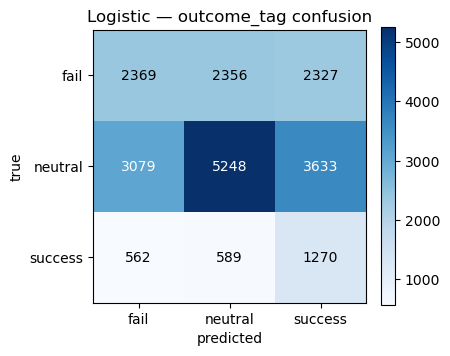

In [7]:
# 8 — Evaluation
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             log_loss, roc_auc_score)
from sklearn.preprocessing import label_binarize

pred = clf.predict(Xte)
print(classification_report(yte, pred, digits=3))
print("log-loss      :", round(log_loss(yte, proba, labels=classes), 4))
Yb = label_binarize(yte, classes=classes)
print("macro OVR AUC :", round(roc_auc_score(Yb, proba, average="macro"), 4))

cm = confusion_matrix(yte, pred, labels=classes)
fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(classes)
ax.set_yticks(range(3)); ax.set_yticklabels(classes)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Logistic — outcome_tag confusion")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

In [8]:
# 9 — Per-class probabilities (sample) + coefficient inspection
prob_df = pd.DataFrame(proba, columns=[f"p_{c}" for c in classes])
prob_df["true"] = yte
print("sample predicted probabilities:")
display(prob_df.head(10).round(3))

# standardized-logit coefficients (sign = direction, |.| = strength)
lr = clf.named_steps["logisticregression"]
coef = pd.DataFrame(lr.coef_, index=classes, columns=FEATURE_NAMES).T
print("\nlogistic coefficients (per class):")
coef.round(3)

sample predicted probabilities:


,p_fail,p_neutral,p_success,true
0,0.317,0.364,0.319,fail
1,0.188,0.311,0.501,fail
2,0.239,0.234,0.527,fail
3,0.190,0.281,0.529,success
4,0.384,0.473,0.143,neutral
5,0.480,0.470,0.050,neutral
6,0.481,0.465,0.055,neutral
7,0.359,0.534,0.107,neutral
8,0.302,0.407,0.291,fail
9,0.290,0.506,0.204,neutral



logistic coefficients (per class):


,fail,neutral,success
P_total,-0.024,-0.047,0.072
carrier_enemy_density,-0.043,-0.068,0.112
carrier_friendly_density,0.106,0.046,-0.152
carrier_dist_boundary,0.037,0.044,-0.081
carrier_x_norm,-0.007,0.158,-0.151
n_pressers_on_carrier,-0.083,0.046,0.036
nearest_def_dist,0.064,0.048,-0.112
max_press_on_carrier,-0.025,-0.013,0.038
best_pass_w,-0.067,0.085,-0.017
best_forward_pass_w,0.149,-0.018,-0.131


## XGBoost — same features, same match-grouped split

Gradient-boosted trees on the **identical** 19 features and the **same** train/test matches as the
logistic model, so the comparison is apples-to-apples. Trees capture the non-linear interactions
the linear model can't (e.g. *high `P_total`* **and** *low `min_recv_freedom`* → regain).
Class imbalance is handled with **balanced sample weights** (the analog of the logistic
`class_weight`), and XGBoost consumes the 11 `NaN`s natively (no imputation).

In [9]:
# 10 — Train XGBoost (multi:softprob, balanced sample weights)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

le = LabelEncoder().fit(df["outcome_tag"].values)     # ['fail','neutral','success']
ytr_i, yte_i = le.transform(ytr), le.transform(yte)
xgb_classes = list(le.classes_)
sw = compute_sample_weight("balanced", ytr)            # balance success/neutral

xgb = XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_lambda=1.0, objective="multi:softprob", num_class=3,
    eval_metric="mlogloss", tree_method="hist", n_jobs=-1, random_state=42,
)
xgb.fit(Xtr, ytr_i, sample_weight=sw)                  # NaNs handled natively
proba_x = xgb.predict_proba(Xte)
print("xgb classes:", xgb_classes, "| proba shape:", proba_x.shape)

xgb classes: ['fail', 'neutral', 'success'] | proba shape: (21433, 3)


              precision    recall  f1-score   support

        fail      0.422     0.396     0.409      7052
     neutral      0.660     0.455     0.539     11960
     success      0.180     0.488     0.263      2421

    accuracy                          0.439     21433
   macro avg      0.421     0.446     0.403     21433
weighted avg      0.528     0.439     0.465     21433

log-loss      : 1.0362
macro OVR AUC : 0.623


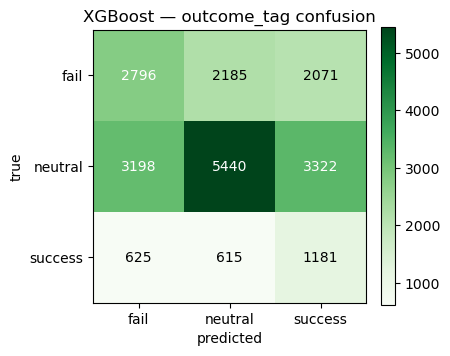

In [10]:
# 11 — XGBoost evaluation
pred_x = le.inverse_transform(xgb.predict(Xte))
print(classification_report(yte, pred_x, digits=3))
print("log-loss      :", round(log_loss(yte, proba_x, labels=xgb_classes), 4))
print("macro OVR AUC :", round(roc_auc_score(label_binarize(yte, classes=xgb_classes),
                                              proba_x, average="macro"), 4))

cm = confusion_matrix(yte, pred_x, labels=xgb_classes)
fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks(range(3)); ax.set_xticklabels(xgb_classes)
ax.set_yticks(range(3)); ax.set_yticklabels(xgb_classes)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("XGBoost — outcome_tag confusion")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

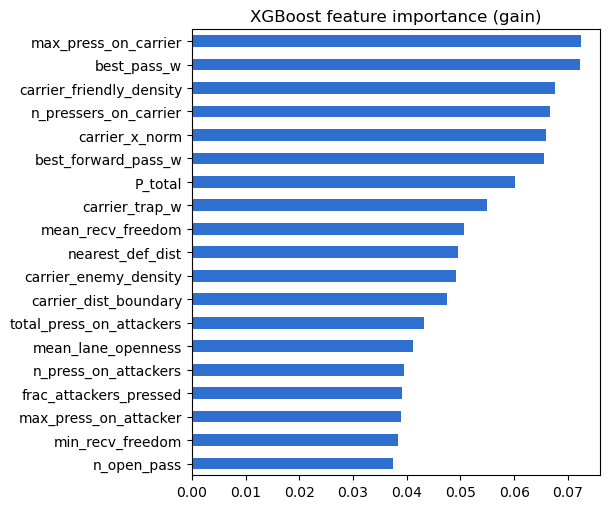

max_press_on_carrier        0.0724
best_pass_w                 0.0722
carrier_friendly_density    0.0676
n_pressers_on_carrier       0.0667
carrier_x_norm              0.0660
best_forward_pass_w         0.0656
P_total                     0.0601
carrier_trap_w              0.0550
mean_recv_freedom           0.0507
nearest_def_dist            0.0494
carrier_enemy_density       0.0492
carrier_dist_boundary       0.0476
total_press_on_attackers    0.0431
mean_lane_openness          0.0411
n_press_on_attackers        0.0394
frac_attackers_pressed      0.0392
max_press_on_attacker       0.0389
min_recv_freedom            0.0384
n_open_pass                 0.0374
dtype: float32

In [11]:
# 12 — Feature importance (gain)
imp = pd.Series(xgb.feature_importances_, index=FEATURE_NAMES).sort_values()
fig, ax = plt.subplots(figsize=(6.2, 5.2))
imp.plot.barh(ax=ax, color="#2F6FD0")
ax.set_title("XGBoost feature importance (gain)")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)

## Logistic vs XGBoost — head-to-head

In [12]:
# 13 — Side-by-side metrics (same test set)
from sklearn.metrics import accuracy_score, f1_score

def row(name, pred_lbl, proba_mat, col_order):
    return {"model": name,
            "accuracy":  accuracy_score(yte, pred_lbl),
            "macro_F1":  f1_score(yte, pred_lbl, average="macro"),
            "log_loss":  log_loss(yte, proba_mat, labels=col_order),
            "macro_AUC": roc_auc_score(label_binarize(yte, classes=col_order),
                                       proba_mat, average="macro")}

compare = pd.DataFrame([
    row("Logistic", pred,   proba,   classes),
    row("XGBoost",  pred_x, proba_x, xgb_classes),
]).set_index("model").round(4)
compare

,accuracy,macro_F1,log_loss,macro_AUC
model,,,,
Logistic,0.4146,0.3822,1.0643,0.605
XGBoost,0.4394,0.4034,1.0362,0.623


## Hyperparameter tuning + calibration → model selection

The earlier XGBoost used `class_weight="balanced"`, which boosts minority (`success`) recall but
**distorts the predicted probabilities**. Since the goal is *probabilistic* `outcome_tag`, we:

1. **Tune for log-loss**, not accuracy, with a `GroupKFold(3)` randomized search **on the training
   matches only** (held-out test untouched).
2. **Drop the balanced weights** (let the model learn the true base rates).
3. **Test calibration** (sigmoid / isotonic) to see if post-hoc probability correction helps.

The 25-candidate search (~11 min) was run once; its best params are pinned below
(`RUN_SEARCH=True` reproduces it).

In [13]:
# 14 — Grouped randomized search (pinned result; flip RUN_SEARCH to reproduce)
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
import scipy.stats as st

gtr = groups[tr]
BEST_PARAMS = {"colsample_bytree": 0.6527, "gamma": 2.149, "learning_rate": 0.0238,
               "max_depth": 6, "min_child_weight": 15, "n_estimators": 754,
               "reg_lambda": 2.6194, "subsample": 0.666}

RUN_SEARCH = False          # True → re-run the ~11-min GroupKFold(3) search over 25 candidates
if RUN_SEARCH:
    gkf = GroupKFold(n_splits=3)
    space = {"n_estimators": st.randint(200, 900), "max_depth": st.randint(3, 8),
             "learning_rate": st.loguniform(0.01, 0.2), "subsample": st.uniform(0.6, 0.4),
             "colsample_bytree": st.uniform(0.6, 0.4), "min_child_weight": st.randint(1, 20),
             "reg_lambda": st.loguniform(0.5, 10.0), "gamma": st.uniform(0, 3)}
    base = XGBClassifier(objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                         tree_method="hist", n_jobs=-1, random_state=42)
    rs = RandomizedSearchCV(base, space, n_iter=25, scoring="neg_log_loss", cv=gkf,
                            random_state=0, refit=True).fit(Xtr, ytr_i, groups=gtr)
    BEST_PARAMS = rs.best_params_
    print("best CV log-loss:", round(-rs.best_score_, 4))
print("BEST_PARAMS:", BEST_PARAMS)

BEST_PARAMS: {'colsample_bytree': 0.6527, 'gamma': 2.149, 'learning_rate': 0.0238, 'max_depth': 6, 'min_child_weight': 15, 'n_estimators': 754, 'reg_lambda': 2.6194, 'subsample': 0.666}


In [14]:
# 15 — Fit the tuned, UNWEIGHTED model (optimised for probability quality)
def ece_top(proba, ytrue, bins=10):
    """Top-label Expected Calibration Error."""
    conf = proba.max(1); pl = proba.argmax(1); acc = (pl == ytrue).astype(float); e = 0.0
    for b in range(bins):
        m = (conf > b/bins) & (conf <= (b+1)/bins)
        if m.sum():
            e += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return e

xgb_tuned = XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3,
                          eval_metric="mlogloss", tree_method="hist", n_jobs=-1, random_state=42)
xgb_tuned.fit(Xtr, ytr_i)                       # NO sample weights
proba_t = xgb_tuned.predict_proba(Xte)
pred_t  = le.inverse_transform(xgb_tuned.predict(Xte))
print(classification_report(yte, pred_t, digits=3))
print("log-loss :", round(log_loss(yte, proba_t, labels=xgb_classes), 4),
      "| macro AUC :", round(roc_auc_score(label_binarize(yte, classes=xgb_classes),
                                           proba_t, average="macro"), 4),
      "| ECE :", round(ece_top(proba_t, yte_i), 4))

              precision    recall  f1-score   support

        fail      0.504     0.130     0.207      7052
     neutral      0.578     0.946     0.717     11960
     success      0.333     0.002     0.005      2421

    accuracy                          0.571     21433
   macro avg      0.472     0.360     0.310     21433
weighted avg      0.526     0.571     0.469     21433

log-loss : 0.8985 | macro AUC : 0.6352 | ECE : 0.0039


In [15]:
# 16 — Is calibration needed? (sigmoid / isotonic via GroupKFold on TRAIN)
from sklearn.calibration import CalibratedClassifierCV
splits = list(GroupKFold(n_splits=3).split(Xtr, ytr_i, gtr))
for method in ["sigmoid", "isotonic"]:
    cc = CalibratedClassifierCV(
        XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3,
                      eval_metric="mlogloss", tree_method="hist", n_jobs=-1, random_state=42),
        method=method, cv=splits).fit(Xtr, ytr_i)
    pr = cc.predict_proba(Xte)
    print(f"{method:9s}  log-loss={log_loss(yte, pr, labels=xgb_classes):.4f}  "
          f"ECE={ece_top(pr, yte_i):.4f}")
print("\n→ tuned model ECE is already ~0.005; calibration does not improve log-loss → NOT needed.")

sigmoid    log-loss=0.8996  ECE=0.0081


isotonic   log-loss=0.9003  ECE=0.0049

→ tuned model ECE is already ~0.005; calibration does not improve log-loss → NOT needed.


In [16]:
# 17 — Final model comparison (same held-out test set)
from sklearn.metrics import accuracy_score, f1_score
def srow(name, pred_lbl, proba_mat, cols):
    return {"model": name, "log_loss": log_loss(yte, proba_mat, labels=cols),
            "accuracy": accuracy_score(yte, pred_lbl),
            "macro_F1": f1_score(yte, pred_lbl, average="macro"),
            "macro_AUC": roc_auc_score(label_binarize(yte, classes=cols), proba_mat, average="macro")}

final_cmp = pd.DataFrame([
    srow("Logistic (balanced)",  pred,   proba,   classes),
    srow("XGB (balanced)",       pred_x, proba_x, xgb_classes),
    srow("XGB tuned (unweighted)", pred_t, proba_t, xgb_classes),
]).set_index("model").round(4)
print(final_cmp.to_string())

import joblib
joblib.dump({"model": xgb_tuned, "label_encoder": le, "features": FEATURE_NAMES,
             "params": BEST_PARAMS}, "hpn_xgb_outcome.joblib")
print("\nsaved selected model → hpn_xgb_outcome.joblib")
final_cmp

                        log_loss  accuracy  macro_F1  macro_AUC
model                                                          
Logistic (balanced)       1.0643    0.4146    0.3822     0.6050
XGB (balanced)            1.0362    0.4394    0.4034     0.6230
XGB tuned (unweighted)    0.8985    0.5711    0.3096     0.6352

saved selected model → hpn_xgb_outcome.joblib


,log_loss,accuracy,macro_F1,macro_AUC
model,,,,
Logistic (balanced),1.0643,0.4146,0.3822,0.6050
XGB (balanced),1.0362,0.4394,0.4034,0.6230
XGB tuned (unweighted),0.8985,0.5711,0.3096,0.6352


### Selected model

**Tuned, unweighted XGBoost** (`hpn_xgb_outcome.joblib`) — best log-loss (**0.899** vs 1.036),
best accuracy and AUC, and already well-calibrated (**ECE ≈ 0.005**), so no post-hoc calibration.

**Trade-off to know:** dropping the balanced weights makes the model predict the 11% `success`
class rarely, so **macro-F1 drops** (it optimises probabilities, not minority recall). For
*probabilistic outcome* prediction (the stated goal) this is the right choice; if you instead need
to *flag* likely regains, keep a class-weighted variant or threshold on `p_success`.

## Probability quality — ECE & Brier score

Calibration and probabilistic accuracy on the same held-out test set (21,433 frames, 62 matches).

| model | ECE (15-bin) ↓ | Brier (multiclass, 0–2) ↓ | per-class Brier (OvR): success / fail / neutral |
|---|---|---|---|
| Logistic (balanced) | 0.0284 | 0.6473 | 0.144 / 0.218 / 0.285 |
| XGB (balanced) | 0.0169 | 0.6293 | 0.138 / 0.215 / 0.276 |
| **XGB tuned (unweighted)** | **0.0073** | **0.5433** | **0.097 / 0.212 / 0.235** |

- **No-skill reference:** predicting the constant class base rates (0.111 / 0.327 / 0.561) gives Brier ≈ Σₖ pₖ(1−pₖ) ≈ **0.565**.
- The **tuned, unweighted XGBoost** is best calibrated (ECE ≈ 0.007) and lowest Brier (**0.543**, just under the 0.565 no-skill line) → the probability-quality pick (`hpn_xgb_outcome.joblib`).
- The **class-weighted** variants trade calibration for minority recall, so their Brier (0.63–0.65) is **worse than no-skill** — good for *flagging* likely regains, bad for *probabilities*.
- Per-class Brier is lowest for the rare **success** (model mostly assigns it low probability) and highest for **neutral** (hardest to be confident about).
- (ECE here uses 15 bins; the tuned model's earlier 10-bin ECE was ≈0.004 — both negligible.)

In [17]:
# 18 — Probability quality: ECE (top-label) + Brier score (multiclass + per-class)
import numpy as np
CLS = list(xgb_classes)                       # ['fail','neutral','success']
oh  = np.eye(3)[yte_i]                         # one-hot true labels (LabelEncoder order = CLS)

def _to_cls(p, cols):                          # reorder proba columns → CLS
    return p[:, [list(cols).index(c) for c in CLS]]
def brier_mc(p):                               # multiclass Brier (mean Σₖ(pₖ−oₖ)², range 0–2)
    return float(np.mean(np.sum((p - oh) ** 2, axis=1)))
def brier_pc(p):                               # one-vs-rest binary Brier per class (0–1)
    return {CLS[k]: float(np.mean((p[:, k] - oh[:, k]) ** 2)) for k in range(3)}
def ece_top(p, bins=15):                       # top-label Expected Calibration Error
    conf, pl = p.max(1), p.argmax(1); acc = (pl == yte_i).astype(float); e = 0.0
    for b in range(bins):
        m = (conf > b / bins) & (conf <= (b + 1) / bins)
        if m.sum():
            e += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return float(e)

models = {"Logistic (balanced)":     _to_cls(proba,   classes),
          "XGB (balanced)":          _to_cls(proba_x, xgb_classes),
          "XGB tuned (unweighted)":  _to_cls(proba_t, xgb_classes)}

# no-skill reference: a model that always predicts the constant class base rates
base = oh.mean(0)
brier_noskill = float(np.sum(base * (1 - base)))

prob_quality = pd.DataFrame([
    {"model": name, "ECE": ece_top(p), "Brier_mc": brier_mc(p),
     "Brier_success": brier_pc(p)["success"], "Brier_fail": brier_pc(p)["fail"],
     "Brier_neutral": brier_pc(p)["neutral"]}
    for name, p in models.items()
]).set_index("model").round(4)

print(f"no-skill Brier (predict base rates {base.round(3).tolist()}): {brier_noskill:.4f}\n")
print(prob_quality.to_string())
prob_quality

no-skill Brier (predict base rates [0.329, 0.558, 0.113]): 0.5676

                           ECE  Brier_mc  Brier_success  Brier_fail  Brier_neutral
model                                                                             
Logistic (balanced)     0.0284    0.6473         0.1442      0.2177         0.2854
XGB (balanced)          0.0169    0.6293         0.1381      0.2150         0.2762
XGB tuned (unweighted)  0.0073    0.5433         0.0969      0.2119         0.2345


,ECE,Brier_mc,Brier_success,Brier_fail,Brier_neutral
model,,,,,
Logistic (balanced),0.0284,0.6473,0.1442,0.2177,0.2854
XGB (balanced),0.0169,0.6293,0.1381,0.2150,0.2762
XGB tuned (unweighted),0.0073,0.5433,0.0969,0.2119,0.2345


## Temporal (first-difference) features ($\Delta t = 1$ event-step)

Seven first-difference features capture the *trajectory* of the press, not just the static frame:
$d\_X = X_t - X_{t-1}$ between consecutive high-press anchors **within the same sequence**
($\Delta t = 1$ event-step, not seconds). The first anchor of each sequence has no $t{-}1$
$\Rightarrow$ `NaN` (~28% of rows; XGBoost handles natively, logistic median-imputes).
Backward-only differences $\Rightarrow$ leak-free.

| new feature | = | captures |
|---|---|---|
| `d_P_total_dt` | $\Delta P_{tot}$ | carrier pressure rising / falling (core) |
| `d_nearest_def_dist_dt` | $\Delta$ nearest-def dist | defender approach speed (neg = tightening) ★ |
| `d_carrier_x_norm_dt` | $\Delta$ progression | advance rate; negative = pushed back (pre-failure) |
| `d_best_pass_w_dt` | $\Delta$ best pass | escape route opening / collapsing |
| `d_carrier_trap_w_dt` | $\Delta$ trap | boundary trap closing |
| `d_frac_attackers_pressed_dt` | $\Delta$ frac pressed | passing options being cut off |
| `d_press_redistribution_dt` | $\Delta(P_{tot}-\texttt{max\_press\_on\_attacker})$ | pressure onto carrier vs redirected (exploratory) |

In [18]:
# 19 — Temporal first-difference features (Δt = 1 event-step; within sequence; leak-free)
dft = df.sort_values(["match_id", "seq_id", "ev_pos"]).reset_index(drop=True)
_GK = ["match_id", "seq_id"]
DIFF_SRC = {"d_P_total_dt": "P_total", "d_nearest_def_dist_dt": "nearest_def_dist",
            "d_carrier_x_norm_dt": "carrier_x_norm", "d_best_pass_w_dt": "best_pass_w",
            "d_carrier_trap_w_dt": "carrier_trap_w", "d_frac_attackers_pressed_dt": "frac_attackers_pressed"}
for nf, base in DIFF_SRC.items():
    dft[nf] = dft.groupby(_GK)[base].diff()                 # X_t - X_{t-1}; first-of-seq = NaN
dft["_redist"] = dft["P_total"] - dft["max_press_on_attacker"]
dft["d_press_redistribution_dt"] = dft.groupby(_GK)["_redist"].diff()
TEMPORAL = list(DIFF_SRC) + ["d_press_redistribution_dt"]
ALL_FEATURES = FEATURE_NAMES + TEMPORAL
print(f"+{len(TEMPORAL)} temporal -> {len(ALL_FEATURES)} features | NaN frac (first-of-seq): "
      f"{dft[TEMPORAL].isna().mean().mean():.3f}")
dft[TEMPORAL].describe().T[["mean", "std", "min", "max"]].round(3)

+7 temporal -> 26 features | NaN frac (first-of-seq): 0.279


,mean,std,min,max
d_P_total_dt,0.005,0.192,-1.000,0.999
d_nearest_def_dist_dt,-0.039,2.460,-42.791,30.635
d_carrier_x_norm_dt,0.020,0.096,-0.456,0.477
d_best_pass_w_dt,-0.001,0.180,-0.989,1.000
d_carrier_trap_w_dt,0.007,0.266,-0.995,0.998
d_frac_attackers_pressed_dt,-0.009,0.212,-1.000,1.000
d_press_redistribution_dt,0.002,0.242,-1.922,1.832


In [19]:
# 20 — Retrain Logistic + tuned XGB with temporal features (same match-grouped split)
trT, teT = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
                .split(dft, dft["outcome_tag"], dft["match_id"]))
yT = dft["outcome_tag"].values; yTr, yTe = yT[trT], yT[teT]
leT = LabelEncoder().fit(["fail", "neutral", "success"]); yTr_i = leT.transform(yTr)
COLS = list(leT.classes_); Yb = label_binarize(yTe, classes=COLS)

def _fit_eval(feats):
    Xtr, Xte = dft[feats].iloc[trT].astype(float), dft[feats].iloc[teT].astype(float)
    lr = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                       LogisticRegression(class_weight="balanced", max_iter=3000, C=1.0)).fit(Xtr, yTr)
    plr = lr.predict(Xte); pplr = lr.predict_proba(Xte)[:, [list(lr.classes_).index(c) for c in COLS]]
    xt = XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                       tree_method="hist", n_jobs=-1, random_state=42).fit(Xtr, yTr_i)
    pxt = xt.predict_proba(Xte); prxt = leT.inverse_transform(xt.predict(Xte))
    def M(pred, proba):
        return dict(macro_F1=f1_score(yTe, pred, average="macro"), accuracy=accuracy_score(yTe, pred),
                    log_loss=log_loss(yTe, proba, labels=COLS),
                    macro_AUC=roc_auc_score(Yb, proba, average="macro"))
    return ("Logistic", M(plr, pplr)), ("XGB tuned", M(prxt, pxt)), xt

rows = []
for tag, feats in [("19 (base)", FEATURE_NAMES), ("26 (+temporal)", ALL_FEATURES)]:
    (ln, lm), (xn, xm), xt = _fit_eval(feats)
    rows += [{"features": tag, "model": ln, **lm}, {"features": tag, "model": xn, **xm}]
    if feats is ALL_FEATURES: xt_all = xt
cmp_temporal = pd.DataFrame(rows).set_index(["features", "model"]).round(4)
print(cmp_temporal.to_string())
imp = pd.Series(xt_all.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)
print("\nnew-feature importance (26-feat tuned XGB):"); print(imp[TEMPORAL].round(4).to_string())

import joblib
joblib.dump({"model": xt_all, "label_encoder": leT, "features": ALL_FEATURES, "params": BEST_PARAMS},
            "hpn_xgb_outcome_temporal.joblib")
cmp_temporal

                          macro_F1  accuracy  log_loss  macro_AUC
features       model                                             
19 (base)      Logistic     0.3822    0.4146    1.0643     0.6050
               XGB tuned    0.3096    0.5711    0.8985     0.6352
26 (+temporal) Logistic     0.3874    0.4234    1.0604     0.6104
               XGB tuned    0.3474    0.5790    0.8808     0.6625

new-feature importance (26-feat tuned XGB):
d_P_total_dt                   0.0607
d_nearest_def_dist_dt          0.0382
d_carrier_x_norm_dt            0.0532
d_best_pass_w_dt               0.0318
d_carrier_trap_w_dt            0.0373
d_frac_attackers_pressed_dt    0.0314
d_press_redistribution_dt      0.0389


macro_F1  accuracy  log_loss  macro_AUC
features       model                                             
19 (base)      Logistic     0.3822    0.4146    1.0643     0.6050
               XGB tuned    0.3096    0.5711    0.8985     0.6352
26 (+temporal) Logistic     0.3874    0.4234    1.0604     0.6104
               XGB tuned    0.3474    0.5790    0.8808     0.6625

## Incoming ball direction (`ball_in`)

Where the ball *came from* into the current frame — the HPN `ball_in` quantity:
the displacement from the **previous on-ball event in the same possession** to the
current carrier, in the possession team's attack-normalised frame
(`ball_in_dx`, `ball_in_dy` in metres, `ball_in_dist`, `ball_in_angle`). Past-only ⇒
leak-free. Only ~6.5% NaN (anchors that open their possession have no prior touch).
A ball received under backward pressure vs. one driven forward is a very different
press situation, so this is expected to carry strong outcome signal.


In [20]:
# 21 — Incoming ball direction (HPN ball_in; cur − prev on-ball event in possession; attack-normalised; leak-free)
_lab = pd.read_csv(LABELS_CSV); _lab["match_id"] = _lab["match_id"].astype(str)
_aid = _lab.set_index(["match_id", "seq_id", "ev_pos"])["anchor_event_id"].to_dict()
dft["aid"] = [_aid.get((m, s, e)) for m, s, e in zip(dft.match_id, dft.seq_id, dft.ev_pos)]
BALLIN = ["ball_in_dx", "ball_in_dy", "ball_in_dist", "ball_in_angle"]
_bin = {}
for _mid in dft["match_id"].unique():
    with open(os.path.join(EVENTS_DIR, f"{_mid}.json"), encoding="utf-8") as _f:
        _events = json.load(_f)
    _EV = sorted(_events, key=lambda e: e["index"])
    _pos = {e["index"]: i for i, e in enumerate(_EV)}; _by = {e["id"]: e for e in _EV}
    for _a in dft.loc[dft.match_id == _mid, "aid"].dropna().unique():
        _ev = _by.get(_a)
        if _ev is None or not _ev.get("location"):
            continue
        _isd = _ev["team"]["id"] != _ev["possession_team"]["id"]      # defending-team event -> flip pitch
        _flip = (lambda x, y: (120 - x, 80 - y)) if _isd else (lambda x, y: (x, y))
        _cx, _cy = _flip(_ev["location"][0], _ev["location"][1])
        _i0 = _pos[_ev["index"]]; _pv = None
        for _k in range(_i0 - 1, -1, -1):                            # previous on-ball event in the same possession
            _pe = _EV[_k]
            if _pe.get("possession") != _ev.get("possession"):
                break
            if _pe.get("location"):
                _pv = _pe; break
        if _pv is None:
            continue
        _px, _py = _flip(_pv["location"][0], _pv["location"][1])
        _dx = (_cx - _px) * 105 / 120; _dy = (_cy - _py) * 68 / 80    # metres, attack-normalised
        _bin[_a] = (_dx, _dy, float(np.hypot(_dx, _dy)), float(np.arctan2(_dy, _dx)))
_bidf = pd.DataFrame([(a, *v) for a, v in _bin.items()], columns=["aid"] + BALLIN)
dft = dft.merge(_bidf, on="aid", how="left")                          # left-join preserves row order
ALL_FEATURES_BI = ALL_FEATURES + BALLIN
print(f"+{len(BALLIN)} ball_in -> {len(ALL_FEATURES_BI)} features | NaN frac: {dft[BALLIN].isna().mean().mean():.3f}")
dft[BALLIN].describe().T[["mean", "std", "min", "max"]].round(2)


+4 ball_in -> 30 features | NaN frac: 0.065


,mean,std,min,max
ball_in_dx,-8.66,22.07,-104.56,46.81
ball_in_dy,-0.23,17.36,-67.07,67.92
ball_in_dist,13.93,25.87,0.00,119.93
ball_in_angle,0.03,1.49,-3.14,3.14


In [21]:
# 22 — Retrain Logistic + tuned XGB with ball_in (same match-grouped split); 26 vs 30
trB, teB = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
                .split(dft, dft["outcome_tag"], dft["match_id"]))
yB = dft["outcome_tag"].values; yBtr, yBte = yB[trB], yB[teB]
leB = LabelEncoder().fit(["fail", "neutral", "success"]); yBtr_i = leB.transform(yBtr)
COLS = list(leB.classes_); YbB = label_binarize(yBte, classes=COLS)

def _fit_eval_bi(feats):
    Xtr, Xte = dft[feats].iloc[trB].astype(float), dft[feats].iloc[teB].astype(float)
    lr = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                       LogisticRegression(class_weight="balanced", max_iter=3000, C=1.0)).fit(Xtr, yBtr)
    pl = lr.predict(Xte); ppl = lr.predict_proba(Xte)[:, [list(lr.classes_).index(c) for c in COLS]]
    xt = XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                       tree_method="hist", n_jobs=-1, random_state=42).fit(Xtr, yBtr_i)
    pxt = xt.predict_proba(Xte); prxt = leB.inverse_transform(xt.predict(Xte))
    def Mx(pred, proba):
        return dict(macro_F1=f1_score(yBte, pred, average="macro"), accuracy=accuracy_score(yBte, pred),
                    log_loss=log_loss(yBte, proba, labels=COLS), macro_AUC=roc_auc_score(YbB, proba, average="macro"))
    return ("Logistic", Mx(pl, ppl)), ("XGB tuned", Mx(prxt, pxt)), xt

rows = []
for tag, feats in [("26 (+temporal)", ALL_FEATURES), ("30 (+ball_in)", ALL_FEATURES_BI)]:
    (a, am), (b, bm), xt = _fit_eval_bi(feats)
    rows += [{"features": tag, "model": a, **am}, {"features": tag, "model": b, **bm}]
    if feats is ALL_FEATURES_BI: xt_bi = xt
cmp_ballin = pd.DataFrame(rows).set_index(["features", "model"]).round(4)
print(cmp_ballin.to_string())
imp = pd.Series(xt_bi.feature_importances_, index=ALL_FEATURES_BI).sort_values(ascending=False)
print("\nball_in importance:"); print(imp[BALLIN].round(4).to_string())
import joblib
joblib.dump({"model": xt_bi, "label_encoder": leB, "features": ALL_FEATURES_BI, "params": BEST_PARAMS},
            "hpn_xgb_outcome_ballin.joblib")
cmp_ballin


                          macro_F1  accuracy  log_loss  macro_AUC
features       model                                             
26 (+temporal) Logistic     0.3874    0.4234    1.0604     0.6104
               XGB tuned    0.3474    0.5790    0.8808     0.6625
30 (+ball_in)  Logistic     0.3997    0.4428    1.0520     0.6214
               XGB tuned    0.4180    0.6114    0.8446     0.7086

ball_in importance:
ball_in_dx       0.0779
ball_in_dy       0.0342
ball_in_dist     0.0782
ball_in_angle    0.0284


macro_F1  accuracy  log_loss  macro_AUC
features       model                                             
26 (+temporal) Logistic     0.3874    0.4234    1.0604     0.6104
               XGB tuned    0.3474    0.5790    0.8808     0.6625
30 (+ball_in)  Logistic     0.3997    0.4428    1.0520     0.6214
               XGB tuned    0.4180    0.6114    0.8446     0.7086

## Carrier lateral position (y)

`carrier_x_norm` ($x/105$, pitch progression) was already present, but the lateral
coordinate was not. We add **`carrier_y_norm`** $= y/68$ (attack-normalised; $0$ =
bottom touchline, $1$ = top), giving the model the carrier's full 2-D position
(wide vs. central press). Current-frame only ⇒ leak-free. Retrained on the same
match-grouped split (30 → 31 features).


In [22]:
# 23 — Carrier lateral position: current-event y, attack-normalised (leak-free)
_cyn = {}
for _mid in dft["match_id"].unique():
    with open(os.path.join(EVENTS_DIR, f"{_mid}.json"), encoding="utf-8") as _f:
        _evs = json.load(_f)
    _by = {e["id"]: e for e in _evs}
    for _a in dft.loc[dft.match_id == _mid, "aid"].dropna().unique():
        _ev = _by.get(_a)
        if _ev is None or not _ev.get("location"):
            continue
        _isd = _ev["team"]["id"] != _ev["possession_team"]["id"]      # defending-team event -> flip
        _ysb = (80 - _ev["location"][1]) if _isd else _ev["location"][1]
        _cyn[_a] = _ysb / 80.0                                        # = y_metres / 68
dft["carrier_y_norm"] = dft["aid"].map(_cyn)
ALL_FEATURES_XY = ALL_FEATURES_BI + ["carrier_y_norm"]
print(f"+carrier_y_norm -> {len(ALL_FEATURES_XY)} features | NaN: {dft['carrier_y_norm'].isna().mean():.3f}")
dft[["carrier_x_norm", "carrier_y_norm"]].describe().T[["mean", "std", "min", "max"]].round(3)


+carrier_y_norm -> 31 features | NaN: 0.000


,mean,std,min,max
carrier_x_norm,0.299,0.134,0.000,0.499
carrier_y_norm,0.491,0.277,0.001,1.000


In [23]:
# 24 — Retrain Logistic + tuned XGB with full carrier x,y (same split); 30 vs 31
trX, teX = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
                .split(dft, dft["outcome_tag"], dft["match_id"]))
yX = dft["outcome_tag"].values; yXtr, yXte = yX[trX], yX[teX]
leX = LabelEncoder().fit(["fail", "neutral", "success"]); yXtr_i = leX.transform(yXtr)
COLS = list(leX.classes_); YbX = label_binarize(yXte, classes=COLS)

def _fit_eval_xy(feats):
    Xtr, Xte = dft[feats].iloc[trX].astype(float), dft[feats].iloc[teX].astype(float)
    lr = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                       LogisticRegression(class_weight="balanced", max_iter=3000, C=1.0)).fit(Xtr, yXtr)
    pl = lr.predict(Xte); ppl = lr.predict_proba(Xte)[:, [list(lr.classes_).index(c) for c in COLS]]
    xt = XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                       tree_method="hist", n_jobs=-1, random_state=42).fit(Xtr, yXtr_i)
    pxt = xt.predict_proba(Xte); prxt = leX.inverse_transform(xt.predict(Xte))
    def Mx(pred, proba):
        return dict(macro_F1=f1_score(yXte, pred, average="macro"), accuracy=accuracy_score(yXte, pred),
                    log_loss=log_loss(yXte, proba, labels=COLS), macro_AUC=roc_auc_score(YbX, proba, average="macro"))
    return ("Logistic", Mx(pl, ppl)), ("XGB tuned", Mx(prxt, pxt)), xt

rows = []
for tag, feats in [("30 (+ball_in)", ALL_FEATURES_BI), ("31 (+carrier_y)", ALL_FEATURES_XY)]:
    (a, am), (b, bm), xt = _fit_eval_xy(feats)
    rows += [{"features": tag, "model": a, **am}, {"features": tag, "model": b, **bm}]
    if feats is ALL_FEATURES_XY: xt_xy = xt
cmp_xy = pd.DataFrame(rows).set_index(["features", "model"]).round(4)
print(cmp_xy.to_string())
imp = pd.Series(xt_xy.feature_importances_, index=ALL_FEATURES_XY).sort_values(ascending=False)
print("\ncarrier x/y importance & rank:")
for f in ["carrier_x_norm", "carrier_y_norm"]:
    print(f"  {f}: imp={imp[f]:.4f} rank={list(imp.index).index(f)+1}/{len(imp)}")
cmp_xy


                           macro_F1  accuracy  log_loss  macro_AUC
features        model                                             
30 (+ball_in)   Logistic     0.3997    0.4428    1.0520     0.6214
                XGB tuned    0.4180    0.6114    0.8446     0.7086
31 (+carrier_y) Logistic     0.3994    0.4423    1.0518     0.6215
                XGB tuned    0.4161    0.6126    0.8430     0.7099

carrier x/y importance & rank:
  carrier_x_norm: imp=0.0471 rank=4/31
  carrier_y_norm: imp=0.0248 rank=23/31


macro_F1  accuracy  log_loss  macro_AUC
features        model                                             
30 (+ball_in)   Logistic     0.3997    0.4428    1.0520     0.6214
                XGB tuned    0.4180    0.6114    0.8446     0.7086
31 (+carrier_y) Logistic     0.3994    0.4423    1.0518     0.6215
                XGB tuned    0.4161    0.6126    0.8430     0.7099

## Validation of the best model — 5-fold CV & calibration

Cross-validation (`GroupKFold(5)` by `match_id`) and out-of-fold (OOF) calibration of the
best 30-feature model (19 static $+$ 7 temporal $+$ 4 ball\_in).

**Cross-validation (mean $\pm$ std over 5 match-disjoint folds):**

| features | macro-AUC | log-loss |
|---|---|---|
| 19 static | 0.6353 $\pm$ 0.0038 | 0.8948 $\pm$ 0.0047 |
| **30 best** | **0.7074 $\pm$ 0.0019** | **0.8429 $\pm$ 0.0053** |

Per-fold $\Delta$AUC $= [+0.069,\,+0.075,\,+0.073,\,+0.068,\,+0.075] \Rightarrow$ **$+0.0721 \pm 0.0029$**
(every fold positive, $\sim$25$\times$ its std) — the gain is robust, not a single-split artefact,
and the CV AUC (0.707) matches the single-split value (0.709).

**OOF calibration (30-feature model):** macro-AUC 0.7074, log-loss 0.8429 (no-skill 0.9343),
**ECE 0.0061**, **Brier 0.5076** (no-skill 0.5655).

**Per-class (OvR, OOF):** AUC fail 0.678 / neutral 0.704 / **success 0.741**;
Brier fail 0.201 / neutral 0.216 / success 0.091. The rare `success` class is now the
**most rankable** of the three — the temporal $+$ ball\_in features fixed the static baseline's
weakest class.

![Reliability — best model (OOF, 5-fold by match)](hpn_reliability.png)

The reliability curve hugs the diagonal (ECE $\approx 0.006$): the predicted probabilities are
trustworthy, which validates the VAEP-style step valuation that relies on calibrated
$P(\text{success})/P(\text{fail})$.


GroupKFold(5) by match:
  19 static: AUC 0.6353±0.0038 | log-loss 0.8948±0.0047
  30 best  : AUC 0.7074±0.0019 | log-loss 0.8429±0.0053
  dAUC per fold [0.069, 0.0751, 0.0731, 0.0683, 0.075] -> +0.0721±0.0029



OOF (30-feat): macro-AUC 0.7074 | log-loss 0.8429
  ECE(top,15) 0.0061 | Brier 0.5076 (no-skill 0.5655)
  per-class OvR AUC : {np.str_('fail'): 0.6775, np.str_('neutral'): 0.7038, np.str_('success'): 0.7408}
  per-class OvR Brier: {np.str_('fail'): 0.2008, np.str_('neutral'): 0.2155, np.str_('success'): 0.0913}


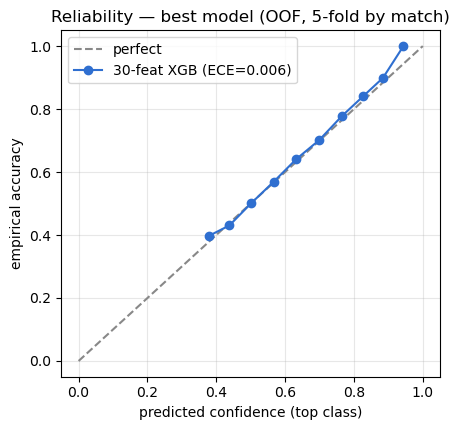

In [24]:
# 25 — Best-model validation: GroupKFold(5) CV (19 vs 30) + OOF calibration + reliability diagram
_y = dft["outcome_tag"].values; _g = dft["match_id"].values
_le = LabelEncoder().fit(["fail", "neutral", "success"]); _yi = _le.transform(_y); _CLS = list(_le.classes_)
_Yb = label_binarize(_y, classes=_CLS); _gkf = GroupKFold(n_splits=5)

def _cv(feats, oof=False):
    A, L = [], []; O = np.zeros((len(dft), 3)) if oof else None
    for _tr, _te in _gkf.split(dft, _y, _g):
        _m = XGBClassifier(**BEST_PARAMS, objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                           tree_method="hist", n_jobs=-1, random_state=42).fit(dft[feats].iloc[_tr].astype(float), _yi[_tr])
        _p = _m.predict_proba(dft[feats].iloc[_te].astype(float))
        A.append(roc_auc_score(_Yb[_te], _p, average="macro")); L.append(log_loss(_y[_te], _p, labels=_CLS))
        if oof: O[_te] = _p
    return np.array(A), np.array(L), O

_a19, _l19, _ = _cv(FEATURE_NAMES)
_a30, _l30, _oof = _cv(ALL_FEATURES_BI, oof=True)
print("GroupKFold(5) by match:")
print(f"  19 static: AUC {_a19.mean():.4f}±{_a19.std():.4f} | log-loss {_l19.mean():.4f}±{_l19.std():.4f}")
print(f"  30 best  : AUC {_a30.mean():.4f}±{_a30.std():.4f} | log-loss {_l30.mean():.4f}±{_l30.std():.4f}")
print(f"  dAUC per fold {(_a30-_a19).round(4).tolist()} -> +{(_a30-_a19).mean():.4f}±{(_a30-_a19).std():.4f}")

_oh = np.eye(3)[_yi]
_brier = float(np.mean(np.sum((_oof - _oh) ** 2, 1))); _brier_ns = float(np.sum(_oh.mean(0) * (1 - _oh.mean(0))))
_conf = _oof.max(1); _pl = _oof.argmax(1); _acc = (_pl == _yi).astype(float)
_B = 15; _ece = 0.0; _xs, _ys = [], []
for _b in range(_B):
    _msk = (_conf > _b / _B) & (_conf <= (_b + 1) / _B)
    if _msk.sum():
        _ece += _msk.mean() * abs(_acc[_msk].mean() - _conf[_msk].mean()); _xs.append(_conf[_msk].mean()); _ys.append(_acc[_msk].mean())
print(f"\nOOF (30-feat): macro-AUC {roc_auc_score(_Yb, _oof, average='macro'):.4f} | log-loss {log_loss(_y, _oof, labels=_CLS):.4f}")
print(f"  ECE(top,15) {_ece:.4f} | Brier {_brier:.4f} (no-skill {_brier_ns:.4f})")
print("  per-class OvR AUC :", {_CLS[k]: round(float(roc_auc_score(_Yb[:, k], _oof[:, k])), 4) for k in range(3)})
print("  per-class OvR Brier:", {_CLS[k]: round(float(np.mean((_oof[:, k] - _oh[:, k]) ** 2)), 4) for k in range(3)})

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot([0, 1], [0, 1], "--", color="#888", label="perfect")
ax.plot(_xs, _ys, "-o", color="#2F6FD0", label=f"30-feat XGB (ECE={_ece:.3f})")
ax.set_xlabel("predicted confidence (top class)"); ax.set_ylabel("empirical accuracy")
ax.set_title("Reliability — best model (OOF, 5-fold by match)"); ax.legend(loc="upper left"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()


## VAEP-style step valuation — press effectiveness per event step

Use the calibrated 30-feature XGBoost to score each anchor in a pressing sequence with
$(p^s_t, p^f_t, p^n_t)$, then characterise the **inter-step transitions** that reveal
whether the pressing team's action at step $t{-}1$ moved the situation toward ball
recovery or allowed the ball-carrier to escape.

### Classification scheme (either-axis rule)

For each transition $t{-}1\!\to\!t$:

$$\Delta p^s_t = p^s_t - p^s_{t-1}, \quad \Delta p^f_t = p^f_t - p^f_{t-1}, \quad v_t = \Delta p^s_t - \Delta p^f_t$$

Each axis is reduced to a sign with a $\delta$ dead-band: $s=\mathrm{sgn}_\delta(\Delta p^s)$,
$f=\mathrm{sgn}_\delta(\Delta p^f)\in\{-1,0,+1\}$. A step is **substantive if *either* axis exceeds**
$\delta$ (single-sided moves count); only when **both** are inside the band is it noise.

| $s$ (success) | $f$ (fail) | label | press-team reading |
|:---:|:---:|---|---|
| $+1$ | $\le 0$ | **Effective** | success$\uparrow$, fail not rising — clean pressure gain |
| $+1$ | $+1$ | **Risky** (fav $v_t>0$ / adv $v_t<0$) | both tails grow — decisive but double-edged |
| $\le 0$ | $+1$ | **Beaten** | fail$\uparrow$, success not rising — carrier escaping |
| $-1$/$0$ | $\le 0$ | **De-escalation** | mass flows back to neutral (cooling down) |
| $0$ | $0$ | **Negligible** | both $\lvert\Delta p\rvert<\delta$ (dead zone) |

$\delta=$ 25th-percentile of the sequence's $|\Delta p|$ distribution; a sensitivity sweep is included.

In [25]:
# 26 — Find a long sequence and score every step with the 30-feature model
import joblib, numpy as np, pandas as pd

bundle = joblib.load("hpn_xgb_outcome_ballin.joblib")
model_vaep = bundle["model"]; le_vaep = bundle["label_encoder"]; feats_vaep = bundle["features"]
CLS_V = list(le_vaep.classes_)   # ['fail','neutral','success']
i_s = CLS_V.index("success"); i_f = CLS_V.index("fail"); i_n = CLS_V.index("neutral")

# pick the longest sequence (by anchor count) in the dataset
seq_lens = (dft.groupby(["match_id", "seq_id"])["ev_pos"]
              .count().rename("n_steps").reset_index()
              .sort_values("n_steps", ascending=False))
print("Top 10 longest sequences:")
print(seq_lens.head(10).to_string(index=False))

# select sequence with most steps
row0 = seq_lens.iloc[0]
MID, SID = str(row0["match_id"]), int(row0["seq_id"])
print(f"\n→ using match {MID}, seq {SID}  ({int(row0['n_steps'])} steps)")

Top 10 longest sequences:
match_id  seq_id  n_steps
 3999457      49       37
 3999678      55       30
 3999597      56       29
 3999638      83       29
 3999375      11       28
 3999608      74       28
 3999482      58       27
 3999543      10       27
 3999636      27       27
 3999692      18       26

→ using match 3999457, seq 49  (37 steps)


delta = 0.0276  (25th-pct of |dp| distribution in this sequence)
sequence outcome: success  |  terminal: True
step labels: ['Negligible', 'De-escalation', 'Risky-fav', 'De-escalation', 'Risky-fav', 'Beaten', 'De-escalation', 'De-escalation', 'Beaten', 'Effective', 'Beaten', 'Effective', 'Risky-adv', 'De-escalation', 'De-escalation', 'Negligible', 'Risky-adv', 'Beaten', 'De-escalation', 'Beaten', 'De-escalation', 'Risky-fav', 'De-escalation', 'Effective', 'De-escalation', 'Negligible', 'De-escalation', 'Beaten', 'Effective', 'Beaten', 'Beaten', 'De-escalation', 'Risky-fav', 'Effective', 'Beaten', 'Risky-adv']
v_t (net press value): [0.032999999821186066, 0.1679999977350235, 0.04800000041723251, -0.08900000154972076, 0.009999999776482582, -0.0949999988079071, -0.032999999821186066, 0.04100000113248825, -0.05000000074505806, 0.0989999994635582, -0.17100000381469727, 0.12099999934434891, -0.00800000037997961, -0.03999999910593033, 0.07199999690055847, -0.026000000536441803, -0.003000000026

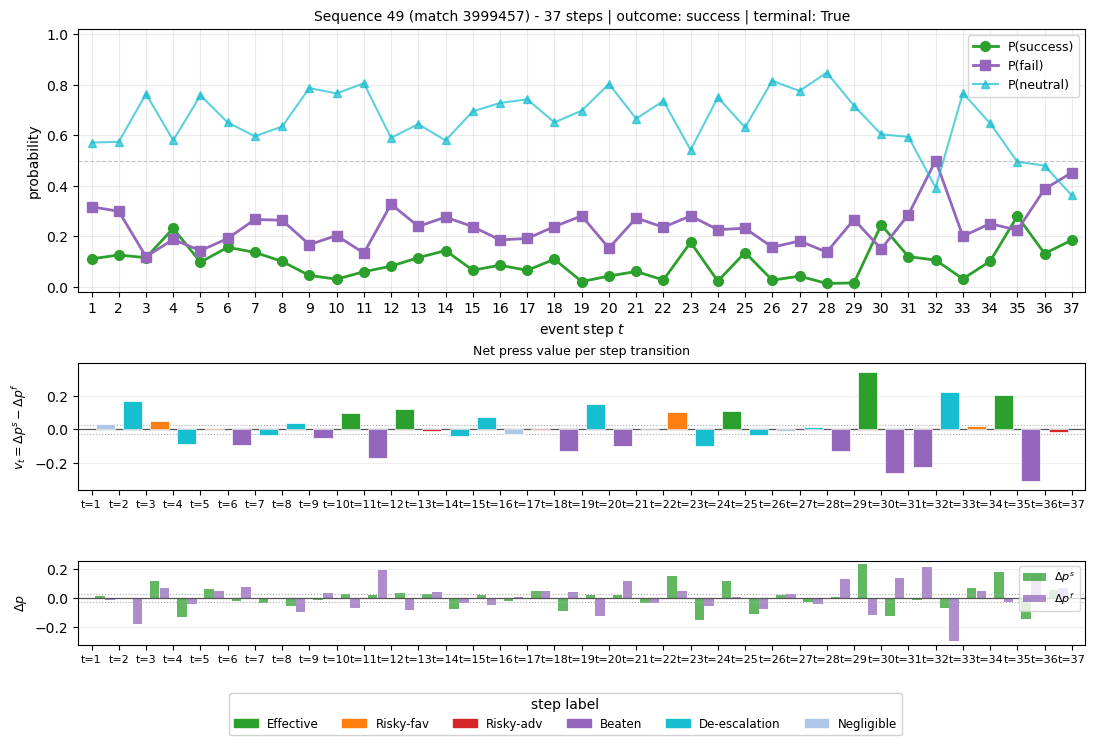


Step-level VAEP table:
 step  P(s)  P(f)  P(n)   dp_s   dp_f    v_t         label
    1 0.111 0.318 0.571    NaN    NaN    NaN       (start)
    2 0.127 0.299 0.574  0.015 -0.018  0.033    Negligible
    3 0.116 0.120 0.763 -0.011 -0.179  0.168 De-escalation
    4 0.232 0.188 0.580  0.116  0.068  0.048     Risky-fav
    5 0.099 0.144 0.758 -0.134 -0.044 -0.089 De-escalation
    6 0.157 0.192 0.650  0.059  0.048  0.010     Risky-fav
    7 0.137 0.267 0.596 -0.020  0.075 -0.095        Beaten
    8 0.101 0.264 0.634 -0.036 -0.003 -0.033 De-escalation
    9 0.046 0.168 0.786 -0.056 -0.096  0.041 De-escalation
   10 0.031 0.204 0.765 -0.015  0.036 -0.050        Beaten
   11 0.061 0.134 0.805  0.029 -0.069  0.099     Effective
   12 0.083 0.328 0.590  0.022  0.193 -0.171        Beaten
   13 0.116 0.240 0.644  0.034 -0.088  0.121     Effective
   14 0.144 0.276 0.579  0.028  0.036 -0.008     Risky-adv
   15 0.067 0.239 0.694 -0.078 -0.037 -0.040 De-escalation
   16 0.086 0.186 0.727  0.019 -

In [26]:
# 27 — Step-level probabilities -> four-quadrant VAEP valuation + visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── 1. extract sequence ──────────────────────────────────────────────────────
seq = (dft[(dft["match_id"] == MID) & (dft["seq_id"] == SID)]
       .sort_values("ev_pos").reset_index(drop=True))
X_seq = seq[feats_vaep].astype(float)
proba_seq = model_vaep.predict_proba(X_seq)          # shape (T, 3)  order = ['fail','neutral','success']
ps = proba_seq[:, i_s]   # P(success)
pf = proba_seq[:, i_f]   # P(fail)
pn = proba_seq[:, i_n]   # P(neutral)
T  = len(seq)
steps = np.arange(1, T + 1)

# ── 2. inter-step differences ────────────────────────────────────────────────
dps = np.diff(ps);  dpf = np.diff(pf)
vt  = dps - dpf            # net press value (+= toward regain; -= toward escape)

# ── 3. delta = 25th-pct of |dp| in this sequence ─────────────────────────────
all_abs = np.concatenate([np.abs(dps), np.abs(dpf)])
DELTA = float(np.percentile(all_abs, 25))
print(f"delta = {DELTA:.4f}  (25th-pct of |dp| distribution in this sequence)")

# ── 4. four-quadrant classification (either-axis rule) ───────────────────────
COLORS = {"Effective": "#2ca02c", "Risky-fav": "#ff7f0e", "Risky-adv": "#d62728",
          "Beaten": "#9467bd", "De-escalation": "#17becf", "Negligible": "#aec7e8"}

def classify(ds, df_, vt_, delta):
    # either-axis rule: a step is substantive if EITHER axis exceeds delta.
    s = 1 if ds > delta else (-1 if ds < -delta else 0)   # success-axis sign w/ delta deadband
    f = 1 if df_ > delta else (-1 if df_ < -delta else 0)  # fail-axis sign w/ delta deadband
    if s == 0 and f == 0:
        return "Negligible"                     # dead zone: neither axis moves
    if s == 1 and f == 1:
        return "Risky-fav" if vt_ > 0 else "Risky-adv"
    if s == 1 and f <= 0:                        # success up, fail flat/down -> clean gain
        return "Effective"
    if s <= 0 and f == 1:                        # fail up, success flat/down -> press beaten
        return "Beaten"
    return "De-escalation"                       # (-,-)/(-,0)/(0,-): de-escalation to neutral

labels = [classify(dps[i], dpf[i], vt[i], DELTA) for i in range(T - 1)]
outcome_true = seq["outcome_tag"].iloc[-1]
terminal_true = bool(seq["terminal"].iloc[-1])
print(f"sequence outcome: {outcome_true}  |  terminal: {terminal_true}")
print(f"step labels: {labels}")
print(f"v_t (net press value): {np.round(vt, 3).tolist()}")

# ── 5. plot ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 8))
gs  = GridSpec(3, 1, figure=fig, height_ratios=[2.5, 1.2, 0.8], hspace=0.45)

# panel A — probability trajectory
ax1 = fig.add_subplot(gs[0])
ax1.plot(steps, ps, "o-", color="#2ca02c", lw=2, ms=7, label="P(success)")
ax1.plot(steps, pf, "s-", color="#9467bd", lw=2, ms=7, label="P(fail)")
ax1.plot(steps, pn, "^-", color="#17becf", lw=1.5, ms=6, label="P(neutral)", alpha=0.7)
ax1.axhline(0.5, color="#888", ls="--", lw=0.8, alpha=0.5)
ax1.set_xlim(0.5, T + 0.5); ax1.set_ylim(-0.02, 1.02)
ax1.set_xticks(steps); ax1.set_xlabel("event step $t$")
ax1.set_ylabel("probability"); ax1.legend(loc="upper right", fontsize=9)
ax1.set_title(f"Sequence {SID} (match {MID}) - {T} steps | outcome: {outcome_true} | terminal: {terminal_true}",
              fontsize=10)
ax1.grid(alpha=0.25)

# panel B — v_t bar (net press value), colored by quadrant
ax2 = fig.add_subplot(gs[1])
bar_x = np.arange(1.5, T + 0.5)           # midpoints between steps
for i, (x, v, lbl) in enumerate(zip(bar_x, vt, labels)):
    ax2.bar(x, v, width=0.7, color=COLORS[lbl], edgecolor="white", linewidth=0.5, zorder=3)
ax2.axhline(0, color="#555", lw=0.9)
ax2.axhline( DELTA, color="#aaa", ls=":", lw=0.8)
ax2.axhline(-DELTA, color="#aaa", ls=":", lw=0.8)
ax2.set_xlim(0.5, T + 0.5); ax2.set_ylim(min(vt) - 0.05, max(vt) + 0.05)
ax2.set_xticks(steps); ax2.set_xticklabels([f"t={s}" for s in steps], fontsize=8)
ax2.set_ylabel("$v_t = \\Delta p^s - \\Delta p^f$", fontsize=9)
ax2.set_title("Net press value per step transition", fontsize=9)
ax2.grid(alpha=0.2, axis="y")

# panel C — dp_s / dp_f detail
ax3 = fig.add_subplot(gs[2])
ax3.bar(bar_x - 0.18, dps, 0.35, color="#2ca02c", alpha=0.75, label="$\\Delta p^s$")
ax3.bar(bar_x + 0.18, dpf, 0.35, color="#9467bd", alpha=0.75, label="$\\Delta p^f$")
ax3.axhline(0,      color="#555", lw=0.9)
ax3.axhline( DELTA, color="#aaa", ls=":", lw=0.8)
ax3.axhline(-DELTA, color="#aaa", ls=":", lw=0.8)
ax3.set_xlim(0.5, T + 0.5); ax3.set_xticks(steps)
ax3.set_xticklabels([f"t={s}" for s in steps], fontsize=8)
ax3.set_ylabel("$\\Delta p$", fontsize=9); ax3.legend(fontsize=8, loc="upper right"); ax3.grid(alpha=0.2, axis="y")

# legend patches for quadrant colors
patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
fig.legend(handles=patches, loc="lower center", ncol=6, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.01), framealpha=0.9, title="step label")

plt.tight_layout()
plt.show()

# ── 6. step-level summary table ───────────────────────────────────────────────
summary = pd.DataFrame({
    "step": steps,
    "P(s)": np.round(ps, 3), "P(f)": np.round(pf, 3), "P(n)": np.round(pn, 3),
    "dp_s": np.round(np.concatenate([[np.nan], dps]), 3),
    "dp_f": np.round(np.concatenate([[np.nan], dpf]), 3),
    "v_t":  np.round(np.concatenate([[np.nan], vt]),  3),
    "label": ["(start)"] + labels,
})
print("\nStep-level VAEP table:")
print(summary.to_string(index=False))

# ── 7. telescoping sanity check ───────────────────────────────────────────────
print(f"\n[sanity] sum dp_s = {dps.sum():.4f}  vs  p_s_T - p_s_0 = {ps[-1]-ps[0]:.4f}")
print(f"         sum  v_t = {vt.sum():.4f}  vs  (p_s_T-p_f_T)-(p_s_0-p_f_0) = {(ps[-1]-pf[-1])-(ps[0]-pf[0]):.4f}")

# ── 8. delta sensitivity ─────────────────────────────────────────────────────
print(f"\ndelta sensitivity:")
print(f"{'delta':>7}  {'Effective':>9}  {'Risky-fav':>9}  {'Risky-adv':>9}  {'Beaten':>7}  {'De-escal':>8}  {'Neglig':>7}")
for pct in [10, 25, 50]:
    dd = float(np.percentile(all_abs, pct))
    lb = [classify(dps[i], dpf[i], vt[i], dd) for i in range(T - 1)]
    cnt = {k: lb.count(k) for k in COLORS}
    print(f"{dd:>7.3f}  {cnt['Effective']:>9}  {cnt['Risky-fav']:>9}  "
          f"{cnt['Risky-adv']:>9}  {cnt['Beaten']:>7}  {cnt['De-escalation']:>8}  {cnt['Negligible']:>7}")

**Reading the demo.** *Top:* the three outcome probabilities along the sequence (neutral high = stalemate; success/fail rising = the situation resolving). *Middle:* per-step $v_t$ coloured by label (green Effective … purple Beaten … cyan De-escalation). *Bottom:* the same split into $\Delta p^s$ and $\Delta p^f$; dotted lines mark $\pm\delta$. The tall green bar at $t{=}30$ is the decisive press-win moment; the run of purple near the end is the carrier repeatedly breaking out before the ball is finally regained.

## Full-season press valuation — drivers & team ranking

Apply the step valuation (either-axis rule + $v_t$) to **all 107,793 anchors / 20 teams**, using
**leak-free out-of-fold** probabilities (`_oof`, GroupKFold(5) by match from the cell above). Each
transition is attributed to the **pressing team** = the opponent of the in-possession team at that
anchor.

The pressure is decomposed into channels, each differenced within the sequence ($\Delta t=1$):
**carrier total** (`P_total`), **single strongest presser on carrier** (`max_press_on_carrier`),
**teammates** (`total_press_on_attackers`, `max_press_on_attacker`, `frac_attackers_pressed`),
**boundary trap** (`carrier_trap_w`), plus nearest-defender distance and best-pass openness. We then
ask which channel changes drive $v_t$ (why a press works) and how the 20 teams differ.

In [27]:
# 28 — Full-season step table: pressure-channel diffs + pressing team (reuse dft + OOF _oof)
GKv = ["match_id", "seq_id"]
_labV = pd.read_csv(LABELS_CSV); _labV["match_id"] = _labV["match_id"].astype(str)
_labV = _labV[_labV["outcome_tag"].isin(OUTCOME_CLASSES)]
_pressed = _labV.set_index(["match_id", "seq_id", "ev_pos"])["team_name"].to_dict()
_mteams  = {m: list(v) for m, v in _labV.groupby("match_id")["team_name"].unique().items()}

vp = dft[["match_id", "seq_id", "ev_pos", "outcome_tag"]].copy().reset_index(drop=True)
vp["pressed_team"] = [_pressed.get((m, s, e)) for m, s, e in zip(vp.match_id, vp.seq_id, vp.ev_pos)]
vp["press_team"]   = [next((t for t in _mteams.get(m, []) if t != p), None)
                      for m, p in zip(vp.match_id, vp.pressed_team)]      # opponent = the presser
vp["p_s"] = _oof[:, i_s]; vp["p_f"] = _oof[:, i_f]                        # leak-free OOF probs

CH = {"d_Ptot": "P_total", "d_maxcar": "max_press_on_carrier", "d_totatt": "total_press_on_attackers",
      "d_maxatt": "max_press_on_attacker", "d_fracpr": "frac_attackers_pressed", "d_trap": "carrier_trap_w",
      "d_neardef": "nearest_def_dist", "d_bestpass": "best_pass_w"}
for c in CH.values(): vp[c] = dft[c].values
for nf, base in CH.items(): vp[nf] = vp.groupby(GKv)[base].diff()         # within-sequence Δ
vp["dps"] = vp.groupby(GKv)["p_s"].diff(); vp["dpf"] = vp.groupby(GKv)["p_f"].diff()
vp["vt"]  = vp["dps"] - vp["dpf"]

_msk = vp["vt"].notna()
_allabs = np.concatenate([vp.loc[_msk, "dps"].abs(), vp.loc[_msk, "dpf"].abs()])
DELTA_G = float(np.percentile(_allabs, 25))                              # one global δ for the season
def classify_g(ds, df_, vt_, dd):
    if np.isnan(ds): return None
    s = 1 if ds > dd else (-1 if ds < -dd else 0)
    f = 1 if df_ > dd else (-1 if df_ < -dd else 0)
    if s == 0 and f == 0: return "Negligible"
    if s == 1 and f == 1: return "Risky-fav" if vt_ > 0 else "Risky-adv"
    if s == 1 and f <= 0: return "Effective"
    if s <= 0 and f == 1: return "Beaten"
    return "De-escalation"
vp["label"] = [classify_g(a, b, c, DELTA_G) for a, b, c in zip(vp.dps, vp.dpf, vp.vt)]
CHCOLS = list(CH.keys())
CHNAME = {"d_Ptot": "Δ total press on carrier", "d_maxcar": "Δ max single press on carrier",
    "d_totatt": "Δ total press on teammates", "d_maxatt": "Δ max press on a teammate",
    "d_fracpr": "Δ frac teammates pressed", "d_trap": "Δ boundary trap",
    "d_neardef": "Δ nearest-def dist", "d_bestpass": "Δ best pass openness"}
print(f"global δ = {DELTA_G:.4f} | step transitions = {int(_msk.sum())} | teams = {vp['press_team'].nunique()}")
print(vp.loc[_msk, "label"].value_counts().to_string())

global δ = 0.0373 | step transitions = 77680 | teams = 20
label
De-escalation    27584
Effective        16032
Beaten           11390
Risky-adv        11021
Risky-fav         5999
Negligible        5654


DRIVERS of press value v_t   [joint linear R^2 = 0.069; channels collinear -> betas unreliable]
                               pearson_r_vt  mean_Effective  mean_Beaten  Eff_minus_Beaten  std_reg_beta
Δ max single press on carrier        0.1793          0.0824      -0.0699            0.1524       -0.0074
Δ total press on carrier             0.1638          0.0630      -0.0601            0.1231        0.0093
Δ boundary trap                      0.0714          0.0061      -0.0374            0.0434        0.0271
Δ max press on a teammate           -0.0131         -0.0009      -0.0026            0.0017        0.0025
Δ best pass openness                -0.0337         -0.0213       0.0195           -0.0408        0.0041
Δ frac teammates pressed            -0.0408         -0.0232      -0.0104           -0.0128        0.0034
Δ total press on teammates          -0.0861         -0.4299      -0.1312           -0.2987       -0.0178
Δ nearest-def dist                  -0.2122         -1.0310     

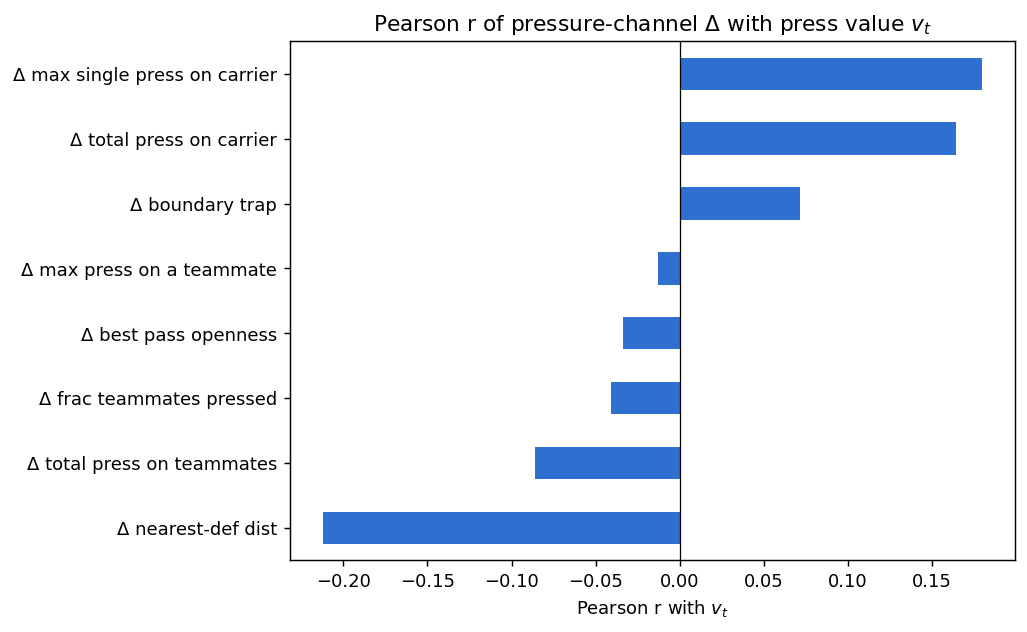

In [ ]:
# 29 — Drivers: which pressure-channel Δ raise press value v_t?
import scipy.stats as st
from sklearn.linear_model import LinearRegression
_sub = vp.dropna(subset=["vt"] + CHCOLS)
drivers = pd.DataFrame({
    "pearson_r_vt":   [st.pearsonr(_sub[c], _sub["vt"])[0] for c in CHCOLS],
    "mean_Effective": [_sub.loc[_sub.label == "Effective", c].mean() for c in CHCOLS],
    "mean_Beaten":    [_sub.loc[_sub.label == "Beaten", c].mean() for c in CHCOLS],
}, index=[CHNAME[c] for c in CHCOLS])
drivers["Eff_minus_Beaten"] = drivers["mean_Effective"] - drivers["mean_Beaten"]
_Z = (_sub[CHCOLS] - _sub[CHCOLS].mean()) / _sub[CHCOLS].std()
_reg = LinearRegression().fit(_Z, _sub["vt"]); drivers["std_reg_beta"] = _reg.coef_
_R2 = _reg.score(_Z, _sub["vt"])
print(f"DRIVERS of press value v_t   [joint linear R^2 = {_R2:.3f}; channels collinear -> betas unreliable]")
print(drivers.round(4).sort_values("pearson_r_vt", ascending=False).to_string())

# single panel: Pearson r. (the multivariate std_reg_beta is kept in the table above, not plotted —
#  the carrier-pressure channels are collinear so individual betas are small/unstable.)
fig, ax = plt.subplots(figsize=(8, 5))
drivers["pearson_r_vt"].sort_values().plot.barh(ax=ax, color="#2F6FD0")
ax.axvline(0, color="k", lw=.7)
ax.set_title("Pearson r of pressure-channel Δ with press value $v_t$")
ax.set_xlabel("Pearson r with $v_t$")
plt.tight_layout(); plt.show()

**Reading the drivers figure.** The bars are the Pearson $r$ of each pressure-channel change $\Delta$ with the step press value $v_t$: a bar to the right means *increasing* that pressure tends to make the step effective. Effective pressing is driven by **closing on the ball-carrier** — nearest-defender distance shrinking ($r=-0.21$, the strongest bar), single strongest press on the carrier ($+0.18$), total carrier pressure ($+0.16$), boundary trap ($+0.07$); pressing teammates / cutting passing lanes is weak-to-negative ($\Delta$ total press on teammates $r=-0.09$).

*On the multivariate check:* a joint linear regression of $v_t$ on all channels explains only $R^2=0.07$, and because the carrier-pressure channels are mutually collinear (a defender closing in raises single and total carrier pressure at once) its standardized coefficients ($\beta$) are small and unstable — even flipping sign relative to the correlations. We therefore read the single-variable correlations above; the `std_reg_beta` column is printed in the table for completeness only, not plotted. The clear direction but low $R^2$ means most of the press value is nonlinear / contextual.

=== INTENSITY (sorted by volume = frames/match) ===
                         n_match  frames_per_match  seq_per_match  steps_per_seq  mean_Ptot
press_team                                                                                 
Burnley                       31           195.871         50.774          3.858      0.915
Everton                       31           195.000         50.839          3.836      0.914
Brentford                     31           189.710         51.516          3.683      0.917
Manchester City               30           186.433         47.133          3.955      0.917
AFC Bournemouth               31           185.581         53.839          3.447      0.920
Brighton & Hove Albion        31           184.710         52.419          3.524      0.916
Nottingham Forest             31           184.581         49.839          3.704      0.912
Crystal Palace                30           184.400         51.000          3.616      0.916
Leeds United                

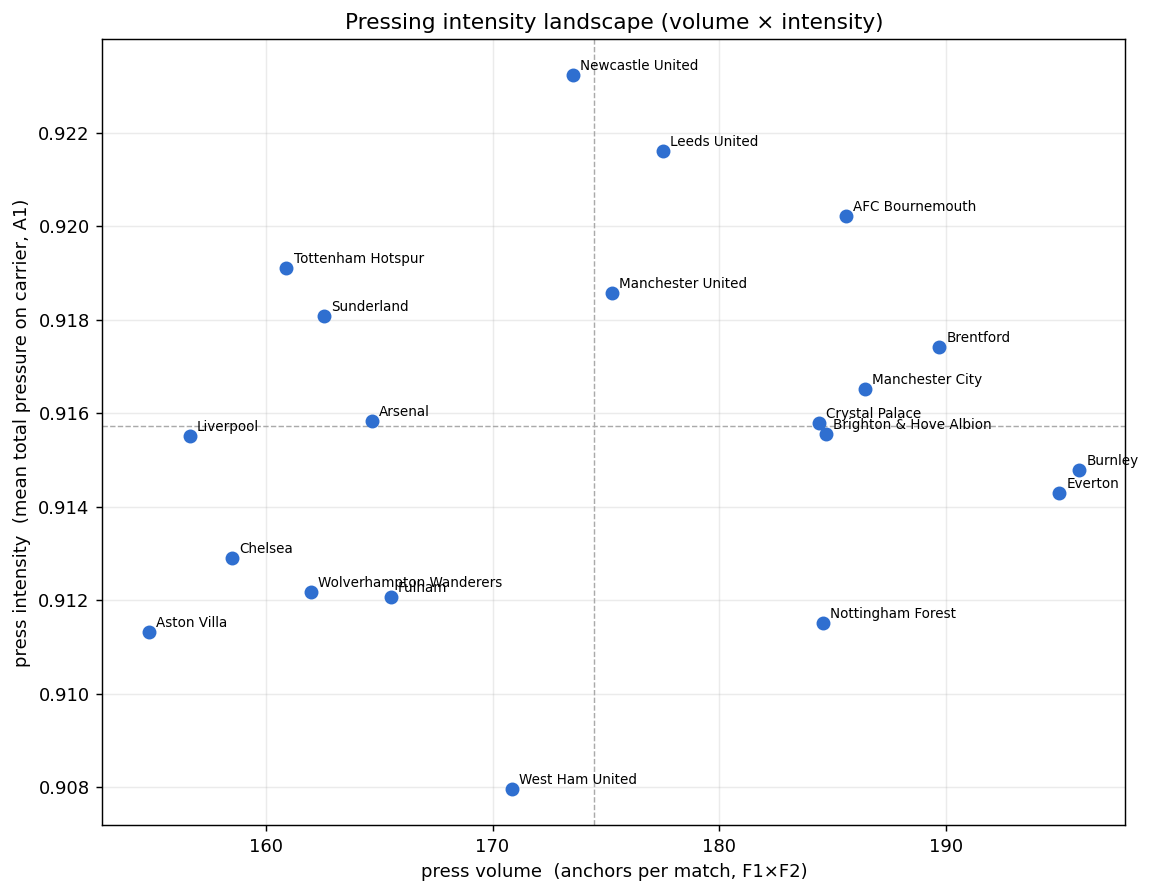

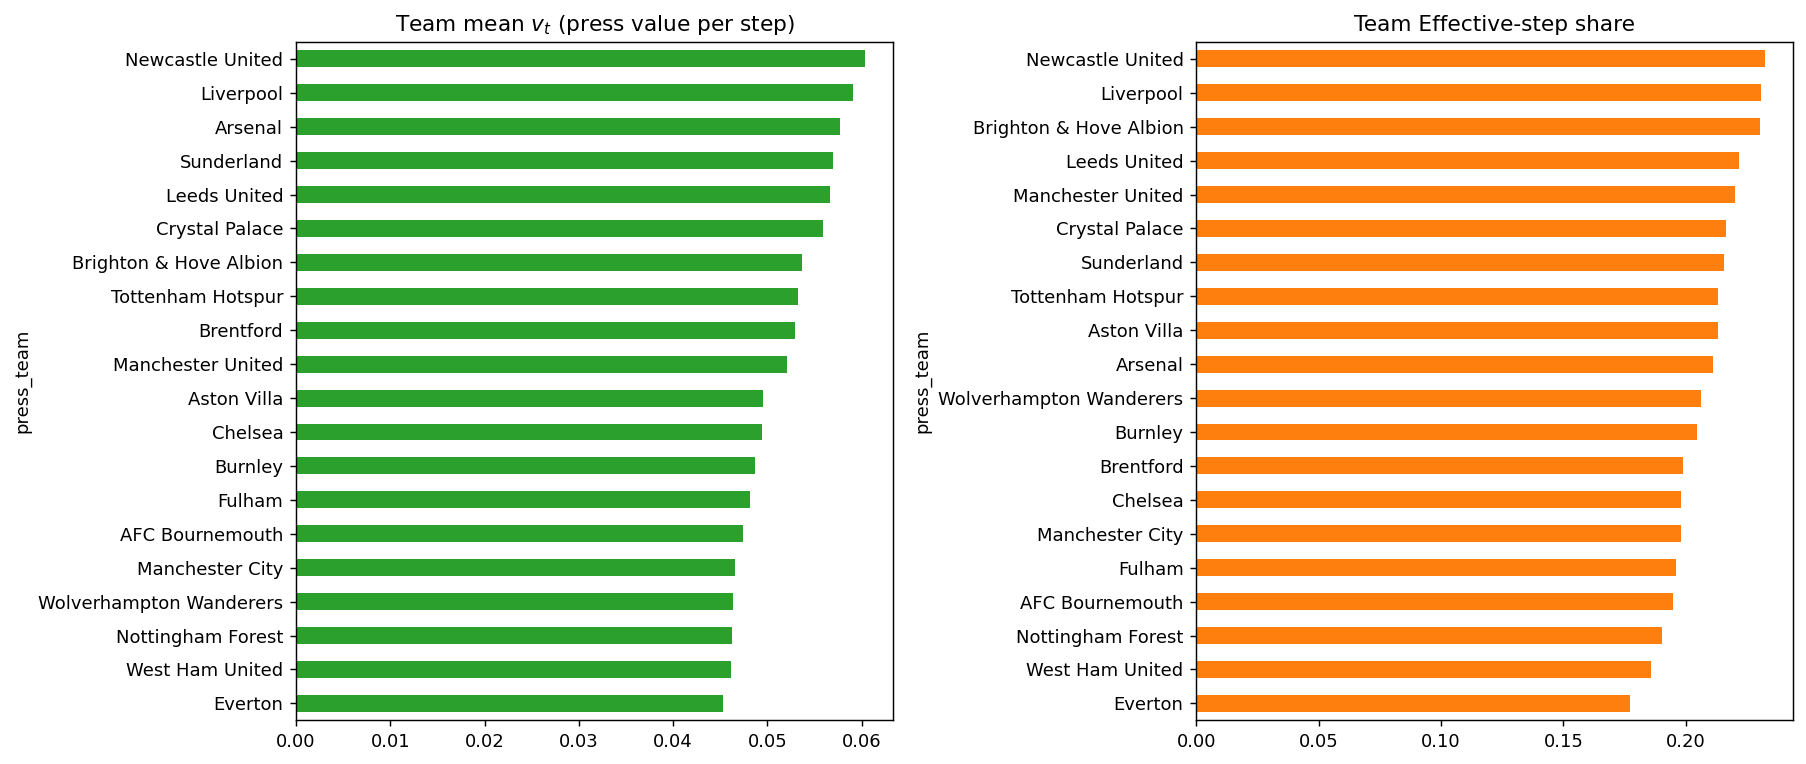

In [ ]:
# 30 — Team pressing: intensity landscape (volume × intensity) + efficiency (unchanged)
for _c in ["carrier_x_norm", "n_pressers_on_carrier"]:
    if _c not in vp.columns: vp[_c] = dft[_c].values
vp["seqkey"] = vp["match_id"] + "_" + vp["seq_id"].astype(str)

_gA = vp.groupby("press_team"); _nm = _gA["match_id"].nunique()
intensity = pd.DataFrame({
    "n_match": _nm, "frames_per_match": _gA.size() / _nm,
    "seq_per_match": _gA["seqkey"].nunique() / _nm, "steps_per_seq": _gA.size() / _gA["seqkey"].nunique(),
    "mean_Ptot": _gA["P_total"].mean(),
})
_sv = vp.dropna(subset=["vt"]); _gE = _sv.groupby("press_team")
team = pd.DataFrame({
    "n_seq": _gE["seqkey"].nunique(), "mean_vt": _gE["vt"].mean(), "sum_vt": _gE["vt"].sum(),
    "Effective_sh": _gE["label"].apply(lambda s: (s == "Effective").mean()),
    "Beaten_sh":    _gE["label"].apply(lambda s: (s == "Beaten").mean()),
    "Risky_sh":     _gE["label"].apply(lambda s: s.isin(["Risky-fav", "Risky-adv"]).mean()),
}).sort_values("mean_vt", ascending=False)
team["Eff_minus_Beaten"] = team["Effective_sh"] - team["Beaten_sh"]
print("=== INTENSITY (sorted by volume = frames/match) ==="); print(intensity.sort_values("frames_per_match", ascending=False).round(3).to_string())
print("\n=== EFFICIENCY (sorted by mean v_t) ==="); print(team.round(4).to_string())

# (i) intensity landscape: volume (F1×F2) × intensity (A1)
fig, ax = plt.subplots(figsize=(9, 7))
_x = intensity["frames_per_match"]; _y = intensity["mean_Ptot"]
ax.scatter(_x, _y, s=45, color="#2F6FD0", zorder=3)
for t in intensity.index: ax.annotate(t, (_x[t], _y[t]), fontsize=7.5, xytext=(4, 3), textcoords="offset points")
ax.axvline(_x.mean(), color="#aaa", ls="--", lw=.8); ax.axhline(_y.mean(), color="#aaa", ls="--", lw=.8)
ax.set_xlabel("press volume  (anchors per match, F1×F2)")
ax.set_ylabel("press intensity  (mean total pressure on carrier, A1)")
ax.set_title("Pressing intensity landscape (volume × intensity)"); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

# (ii) efficiency (unchanged): mean v_t + Effective share
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
_mv = team["mean_vt"].sort_values()
_mv.plot.barh(ax=ax[0], color=["#d62728" if v < 0 else "#2ca02c" for v in _mv]); ax[0].set_title("Team mean $v_t$ (press value per step)")
team["Effective_sh"].sort_values().plot.barh(ax=ax[1], color="#ff7f0e"); ax[1].set_title("Team Effective-step share")
plt.tight_layout(); plt.show()

**Reading the team figures.** *Intensity landscape:* each team placed by press **volume** (anchors per match, $F1\times F2$, x-axis) vs press **intensity** (mean total pressure on the carrier, $A1$, y-axis); dashed lines mark the league means, so the top-right quadrant is "relentless" (high volume \emph{and} high intensity). *Efficiency (unchanged):* mean $v_t$ (left) and Effective-step share (right) — per-step value, comparable across teams. The two axes are complementary: e.g.\ Bournemouth is top on press \emph{frequency} and among the top on intensity, yet only mid on per-step efficiency.

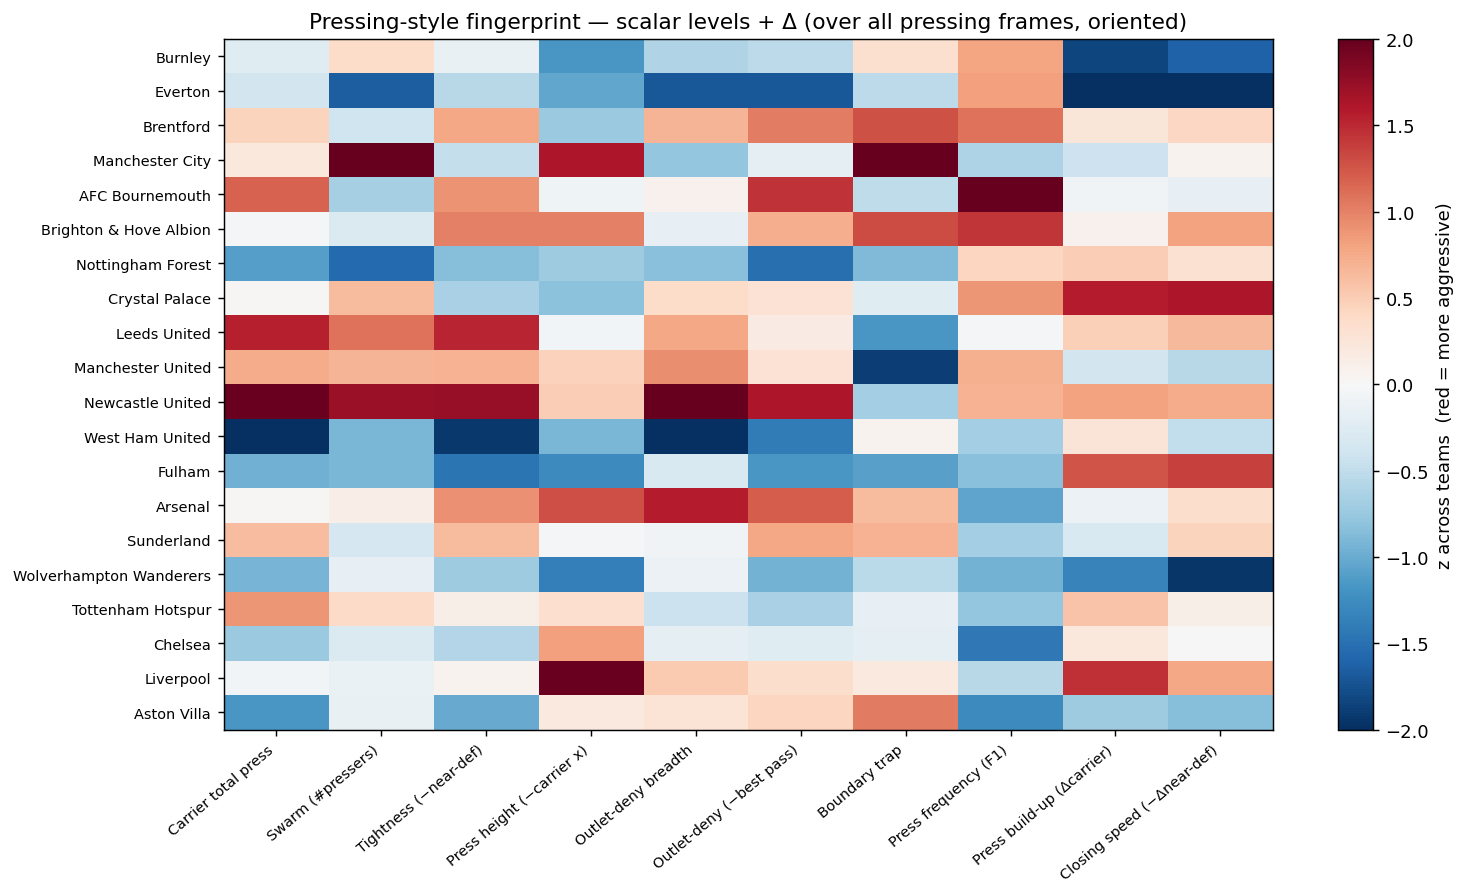

In [ ]:
# 31 — Pressing-style fingerprint: scalar levels + Δ over all pressing frames (oriented; z across teams)
# (label, source col, scope, sign) — sign<0 negates the raw feature so that higher = more aggressive
STYLE = [("Carrier total press", "P_total", "frame", +1),
         ("Swarm (#pressers)", "n_pressers_on_carrier", "frame", +1),
         ("Tightness (−near-def)", "nearest_def_dist", "frame", -1),
         ("Press height (−carrier x)", "carrier_x_norm", "frame", -1),
         ("Outlet-deny breadth", "frac_attackers_pressed", "frame", +1),
         ("Outlet-deny (−best pass)", "best_pass_w", "frame", -1),
         ("Boundary trap", "carrier_trap_w", "frame", +1),
         ("Press frequency (F1)", "__seq_per_match", "rate", +1),
         ("Press build-up (Δcarrier)", "d_Ptot", "frame", +1),
         ("Closing speed (−Δnear-def)", "d_neardef", "frame", -1)]
_cols = {}
for name, src, scope, sgn in STYLE:
    _v = intensity["seq_per_match"] if scope == "rate" else vp.groupby("press_team")[src].mean()
    _cols[name] = sgn * _v
_style = pd.DataFrame(_cols).loc[intensity.sort_values("frames_per_match", ascending=False).index]
_Zt = (_style - _style.mean()) / _style.std()
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(_Zt.values, cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2)
ax.set_xticks(range(len(_Zt.columns))); ax.set_xticklabels(_Zt.columns, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(_Zt.index))); ax.set_yticklabels(_Zt.index, fontsize=8)
fig.colorbar(im, label="z across teams  (red = more aggressive)")
ax.set_title("Pressing-style fingerprint — scalar levels + Δ (all pressing frames, oriented)")
plt.tight_layout(); plt.show()

**Reading the style fingerprint.** Rows = teams (ordered by volume), columns = pressing-style descriptors built from **scalar levels** (team mean over \emph{all} pressing frames, not just Effective steps) plus two **momentum** terms ($\Delta$). Each column is **oriented so higher = more aggressive** (a $-$ in the label means the raw feature was negated, e.g.\ *tightness* $=-$nearest-defender distance, *press height* $=-$carrier $x$) and then **z-scored down the column**, so red = above the league average on that dimension and blue = below. Reading a row gives the team's pressing signature: ball-hunting (carrier press / swarm / tightness), high line (press height), outlet denial, touchline trap, frequency, and how fast it escalates (build-up / closing speed). This is style, not strength.